# ODMR post-saturation-fix bias analysis — signal trace only

Data source: `nv_magnetometer_project/data/ODMR_post_saturation_fix`.

This notebook compares the July 7 ODMR sweeps after the saturation fix using the **MW-on signal trace** as the primary ODMR measurement. The CSV `contrast_ADC` and `contrast_percent` columns are intentionally ignored in this analysis.

Here, “contrast” means the dip transmission in the signal trace:

\[
T_\mathrm{dip} = 100\,\frac{S_\mathrm{min}}{S_\mathrm{bright}}, \qquad
\mathrm{dip\ depth} = 100 - T_\mathrm{dip}.
\]

Metrics included:
- MW-on signal bright PL baseline (`S_bright`, 90th percentile ADC).
- Signal dip transmission and signal dip depth.
- Signal-only structure-aware ODMR sensitivity using the same helper module as the ODMR module notebook.
- MW-off PL is kept only as a brightness/reference context metric, not as the ODMR ranking trace.

Expanded EDA additions in this version:
- Model-free signal dip width and integrated dip area.
- Frequency-by-bias heatmaps of normalized MW-on signal transmission.
- Sensitivity component plots showing slope, noise, and resulting eta separately.
- Tradeoff scatter plots and metric-correlation heatmaps to show which metric is driving the trend.



In [1]:

%matplotlib inline

import csv
import html
import math
import re
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

ABS_PROJECT_ROOT = Path('/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project')

search_roots = []
for p in [Path.cwd(), *Path.cwd().parents]:
    search_roots.append(p)
    search_roots.append(p / 'nv_magnetometer_project')
search_roots.append(ABS_PROJECT_ROOT)

PROJECT_ROOT = next(
    p for p in search_roots
    if (p / 'data' / 'ODMR_post_saturation_fix').exists()
    and (p / 'notebook_modules' / 'odmr_sensitivity.py').exists()
)
DATA_DIR = PROJECT_ROOT / 'data' / 'ODMR_post_saturation_fix'
NOTEBOOK_DIR = PROJECT_ROOT / 'data' / 'notebooks'

sys.path.insert(0, str(PROJECT_ROOT / 'notebook_modules'))
from odmr_sensitivity import DEFAULT_POINT_TIME_S, estimate_odmr_sensitivity, estimate_sensitivity

plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

DATA_DIR, NOTEBOOK_DIR, DEFAULT_POINT_TIME_S


(PosixPath('/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/ODMR_post_saturation_fix'),
 PosixPath('/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks'),
 0.000213)

## Loader and signal-only sensitivity helpers

Only these columns are required:
- `frequency_MHz`
- `photoluminescence_mw_on_ADC` → signal / first trace / ODMR trace for ranking
- `photoluminescence_mw_off_ADC` → brightness context only

The CSV contrast columns can exist in the files, but no metric below reads them.


In [2]:

BIAS_RE = re.compile(r'_(?P<bias>\d+\.\d+)VBias(?:_(?P<repeat>\d+))?\.csv$')
GUARD_RETRIES_MHZ = (18.0, 10.0, 6.0, 3.0, 0.0)
MIN_CLEAN_POINTS = 10

class SignalODMRData:
    def __init__(self, frequency_mhz, signal_adc, reference_adc=None):
        self.frequencies = np.asarray(frequency_mhz, dtype=float)
        self.signal = np.asarray(signal_adc, dtype=float)
        if reference_adc is not None:
            self.reference = np.asarray(reference_adc, dtype=float)


def read_odmr_csv(path):
    with open(path, newline='') as fh:
        rows = list(csv.DictReader(fh))
    if not rows:
        raise ValueError(f'Empty CSV: {path}')
    cols = {name: np.array([float(row[name]) for row in rows], dtype=float) for name in rows[0]}
    required = {'frequency_MHz', 'photoluminescence_mw_on_ADC', 'photoluminescence_mw_off_ADC'}
    missing = required.difference(cols)
    if missing:
        raise ValueError(f'{path.name} missing required columns: {sorted(missing)}')
    return cols


def parse_bias_label(path):
    m = BIAS_RE.search(path.name)
    if not m:
        return {
            'bias_v': np.nan,
            'repeat': np.nan,
            'bias_label': 'Best_Sensitivity (bias not in filename)',
            'is_labeled_bias': False,
        }
    bias = float(m.group('bias'))
    repeat = int(m.group('repeat') or 0)
    return {
        'bias_v': bias,
        'repeat': repeat,
        'bias_label': f'{bias:.2f} V',
        'is_labeled_bias': True,
    }


def signal_result_is_usable(result, min_clean_points=0):
    if result is None or 'signal' not in result:
        return False
    eta = result['signal'].get('sensitivity_t_rt_hz', np.nan)
    clean = result['signal'].get('n_clean_points', 999)
    return np.isfinite(eta) and clean >= min_clean_points


def force_signal_best(result, min_clean_points=0):
    if not signal_result_is_usable(result, min_clean_points=min_clean_points):
        raise ValueError(f'No finite signal sensitivity with >= {min_clean_points} clean baseline points')
    result = dict(result)
    result['best'] = 'signal'
    return result


def run_quick_signal_estimate(data):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            result = estimate_sensitivity(
                data,
                traces=('signal',),
                point_time_s=DEFAULT_POINT_TIME_S,
            )
        return force_signal_best(result, min_clean_points=0), 'quick_signal_default_guard_18', ''
    except Exception as exc:
        return None, 'quick_signal_failed', f'{type(exc).__name__}: {exc}'


def run_robust_signal_estimate(data):
    errors = []
    for guard in GUARD_RETRIES_MHZ:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                result = estimate_sensitivity(
                    data,
                    traces=('signal',),
                    point_time_s=DEFAULT_POINT_TIME_S,
                    noise_guard_mhz=guard,
                )
            result = force_signal_best(result, min_clean_points=MIN_CLEAN_POINTS)
            return result, f'signal_guard_{guard:g}', ''
        except Exception as exc:
            errors.append(f'{guard:g}:{type(exc).__name__}')

    # Last-resort compatibility with the older single-Lorentzian estimate, still on signal only.
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            legacy = estimate_odmr_sensitivity(data, trace='signal', point_time_s=DEFAULT_POINT_TIME_S)
        legacy = legacy['signal'] if isinstance(legacy, dict) and 'signal' in legacy else legacy
        result = {
            'best': 'signal',
            'point_time_s': DEFAULT_POINT_TIME_S,
            'signal': {
                'trace': 'signal',
                'sensitivity_t_rt_hz': legacy['sensitivity_t_rt_hz'],
                'sensitivity_t_rt_hz_white': np.nan,
                'slope_adc_per_mhz': np.nan,
                'noise_baseline': legacy.get('noise_std', np.nan),
                'noise_white': np.nan,
                'n_clean_points': np.nan,
                'f_at_slope_mhz': legacy.get('center_mhz', np.nan),
                'n_lines': 1,
            },
        }
        return result, 'legacy_signal_fallback', ';'.join(errors)
    except Exception as exc:
        return None, 'signal_sensitivity_failed', ';'.join(errors + [f'legacy:{type(exc).__name__}'])


def fmt_float(value, digits=3):
    try:
        if value is None or not np.isfinite(value):
            return ''
    except TypeError:
        return str(value)
    return f'{float(value):.{digits}f}'


def html_table(rows, columns, max_rows=None):
    shown = rows if max_rows is None else rows[:max_rows]
    head = ''.join(f'<th>{html.escape(label)}</th>' for _, label, _ in columns)
    body_rows = []
    for row in shown:
        tds = []
        for key, _, digits in columns:
            value = row.get(key, '')
            if isinstance(value, (float, np.floating)):
                text = fmt_float(value, digits)
            else:
                text = '' if value is None else str(value)
            tds.append(f'<td>{html.escape(text)}</td>')
        body_rows.append('<tr>' + ''.join(tds) + '</tr>')
    note = '' if max_rows is None or len(rows) <= max_rows else f'<p>Showing {max_rows} of {len(rows)} rows.</p>'
    return note + '<table><thead><tr>' + head + '</tr></thead><tbody>' + ''.join(body_rows) + '</tbody></table>'


def nanmedian(values):
    arr = np.asarray(values, dtype=float)
    return float(np.nanmedian(arr)) if np.isfinite(arr).any() else np.nan


def nanstd(values):
    arr = np.asarray(values, dtype=float)
    return float(np.nanstd(arr, ddof=1)) if np.isfinite(arr).sum() >= 2 else np.nan


## Load all sweeps


In [3]:

paths = sorted(DATA_DIR.glob('*.csv'))
print(f'Found {len(paths)} ODMR CSV files in {DATA_DIR}')
for path in paths:
    print('  ', path.name)


Found 25 ODMR CSV files in /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/ODMR_post_saturation_fix
   odmr_sweep_20260707_112045_0.44VBias_1.csv
   odmr_sweep_20260707_112105_0.44VBias_2.csv
   odmr_sweep_20260707_112130_0.44VBias_3.csv
   odmr_sweep_20260707_112159_0.45VBias_1.csv
   odmr_sweep_20260707_112219_0.45VBias_2.csv
   odmr_sweep_20260707_112234_0.45VBias_3.csv
   odmr_sweep_20260707_112300_0.46VBias_1.csv
   odmr_sweep_20260707_112324_0.46VBias_2.csv
   odmr_sweep_20260707_112342_0.46VBias_3.csv
   odmr_sweep_20260707_112418_0.47VBias_1.csv
   odmr_sweep_20260707_112436_0.47VBias_2.csv
   odmr_sweep_20260707_112454_0.47VBias_3.csv
   odmr_sweep_20260707_112528_0.48VBias_1.csv
   odmr_sweep_20260707_112550_0.48VBias_2.csv
   odmr_sweep_20260707_112604_0.48VBias_3.csv
   odmr_sweep_20260707_112700_0.49VBias_1.csv
   odmr_sweep_20260707_112716_0.49VBias_2.csv
   odmr_sweep_20

In [4]:

sweeps = []
raw_by_file = {}

for path in paths:
    cols = read_odmr_csv(path)
    raw_by_file[path.name] = cols
    label = parse_bias_label(path)

    freq = cols['frequency_MHz']
    signal = cols['photoluminescence_mw_on_ADC']
    reference = cols['photoluminescence_mw_off_ADC']
    data = SignalODMRData(freq, signal, reference)

    quick_result, quick_method, quick_error = run_quick_signal_estimate(data)
    robust_result, robust_method, robust_error = run_robust_signal_estimate(data)

    q = quick_result['signal'] if quick_result is not None and 'signal' in quick_result else {}
    r = robust_result['signal'] if robust_result is not None and 'signal' in robust_result else {}

    signal_bright = float(np.percentile(signal, 90))
    signal_dark = float(np.percentile(signal, 10))
    signal_min_idx = int(np.argmin(signal))
    signal_min = float(signal[signal_min_idx])
    signal_dip_depth_adc = signal_bright - signal_min
    signal_dip_depth_percent = 100.0 * signal_dip_depth_adc / signal_bright
    signal_dip_transmission_percent = 100.0 * signal_min / signal_bright

    rec = {
        'file': path.name,
        'timestamp': re.search(r'odmr_sweep_(\d{8}_\d{6})', path.name).group(1),
        **label,
        'n_points': int(len(freq)),
        'freq_min_mhz': float(np.min(freq)),
        'freq_max_mhz': float(np.max(freq)),
        'signal_bright_p90_adc': signal_bright,
        'signal_dark_p10_adc': signal_dark,
        'signal_median_adc': float(np.median(signal)),
        'reference_bright_p90_adc': float(np.percentile(reference, 90)),
        'reference_median_adc': float(np.median(reference)),
        'signal_min_adc': signal_min,
        'signal_dip_depth_adc': float(signal_dip_depth_adc),
        'signal_dip_depth_percent': float(signal_dip_depth_percent),
        'signal_dip_transmission_percent': float(signal_dip_transmission_percent),
        'freq_at_signal_min_mhz': float(freq[signal_min_idx]),
        'signal_ptp_adc': float(np.ptp(signal)),
        'signal_ptp_percent_of_bright': float(100.0 * np.ptp(signal) / signal_bright),
        'quick_method': quick_method,
        'quick_error': quick_error,
        'quick_eta_white_nT': float(q.get('sensitivity_t_rt_hz_white', np.nan) * 1e9),
        'quick_eta_baseline_nT': float(q.get('sensitivity_t_rt_hz', np.nan) * 1e9),
        'quick_n_clean': float(q.get('n_clean_points', np.nan)),
        'robust_method': robust_method,
        'robust_error': robust_error,
        'robust_eta_white_nT': float(r.get('sensitivity_t_rt_hz_white', np.nan) * 1e9),
        'robust_eta_baseline_nT': float(r.get('sensitivity_t_rt_hz', np.nan) * 1e9),
        'robust_slope_adc_per_mhz': float(r.get('slope_adc_per_mhz', np.nan)),
        'robust_noise_white_adc': float(r.get('noise_white', np.nan)),
        'robust_noise_baseline_adc': float(r.get('noise_baseline', np.nan)),
        'robust_n_clean': float(r.get('n_clean_points', np.nan)),
        'robust_f_at_slope_mhz': float(r.get('f_at_slope_mhz', np.nan)),
        'robust_n_lines': float(r.get('n_lines', np.nan)),
    }
    sweeps.append(rec)

print(f'Computed signal-only metrics for {len(sweeps)} sweeps. Point dwell used by helper: {DEFAULT_POINT_TIME_S*1e6:.0f} us')
print('CSV contrast_ADC / contrast_percent columns were not read for any metric.')


Computed signal-only metrics for 25 sweeps. Point dwell used by helper: 213 us
CSV contrast_ADC / contrast_percent columns were not read for any metric.


## Per-sweep signal table

`signal_dip_transmission_percent` is the minimum signal divided by the bright signal baseline. Lower transmission means a deeper ODMR dip. `signal_dip_depth_percent = 100 - signal_dip_transmission_percent`.


In [5]:

from IPython.display import HTML, display

sweep_cols = [
    ('bias_label', 'bias', 2),
    ('repeat', 'rep', 0),
    ('file', 'file', 0),
    ('signal_bright_p90_adc', 'signal bright p90 ADC', 1),
    ('signal_dip_transmission_percent', 'signal dip transmission %', 3),
    ('signal_dip_depth_percent', 'signal dip depth %', 3),
    ('freq_at_signal_min_mhz', 'signal min MHz', 1),
    ('quick_eta_baseline_nT', 'quick signal eta nT/sqrtHz', 2),
    ('quick_n_clean', 'quick clean pts', 0),
    ('robust_eta_baseline_nT', 'robust signal eta nT/sqrtHz', 2),
    ('robust_method', 'robust method', 0),
]

ordered_sweeps = sorted(sweeps, key=lambda r: (np.inf if not np.isfinite(r['bias_v']) else r['bias_v'], r['repeat'] if np.isfinite(r['repeat']) else 99, r['file']))
display(HTML(html_table(ordered_sweeps, sweep_cols)))


bias,rep,file,signal bright p90 ADC,signal dip transmission %,signal dip depth %,signal min MHz,quick signal eta nT/sqrtHz,quick clean pts,robust signal eta nT/sqrtHz,robust method
0.44 V,1,odmr_sweep_20260707_112045_0.44VBias_1.csv,16532.0,95.183,4.817,2867.0,18.13,288,18.13,signal_guard_18
0.44 V,2,odmr_sweep_20260707_112105_0.44VBias_2.csv,16517.2,95.195,4.805,2867.0,15.57,274,15.57,signal_guard_18
0.44 V,3,odmr_sweep_20260707_112130_0.44VBias_3.csv,16494.6,95.205,4.795,2867.0,14.67,281,14.67,signal_guard_18
0.45 V,1,odmr_sweep_20260707_112159_0.45VBias_1.csv,16476.0,95.185,4.815,2867.0,11.03,274,11.03,signal_guard_18
0.45 V,2,odmr_sweep_20260707_112219_0.45VBias_2.csv,15674.5,95.094,4.906,2867.0,12.49,274,12.49,signal_guard_18
0.45 V,3,odmr_sweep_20260707_112234_0.45VBias_3.csv,15663.3,95.103,4.897,2867.0,12.61,278,12.61,signal_guard_18
0.46 V,1,odmr_sweep_20260707_112300_0.46VBias_1.csv,15662.7,95.076,4.924,2867.0,12.06,273,12.06,signal_guard_18
0.46 V,2,odmr_sweep_20260707_112324_0.46VBias_2.csv,14763.6,94.974,5.026,2867.0,11.63,273,11.63,signal_guard_18
0.46 V,3,odmr_sweep_20260707_112342_0.46VBias_3.csv,14756.9,94.991,5.009,2867.0,11.50,270,11.50,signal_guard_18
0.47 V,1,odmr_sweep_20260707_112418_0.47VBias_1.csv,14808.9,94.973,5.027,2867.0,12.57,272,12.57,signal_guard_18


## Bias-level summary

The labeled voltage groups have three repeats each. The unlabeled `Best_Sensitivity` file is listed separately and should not be assigned a bias unless the acquisition setting is confirmed elsewhere.


In [6]:

groups = defaultdict(list)
for rec in sweeps:
    groups[rec['bias_label']].append(rec)

def group_sort_key(item):
    label, rows = item
    bias = rows[0]['bias_v']
    return (np.inf if not np.isfinite(bias) else bias, label)

bias_summary = []
for label, rows in sorted(groups.items(), key=group_sort_key):
    best_row = min(rows, key=lambda r: np.inf if not np.isfinite(r['robust_eta_baseline_nT']) else r['robust_eta_baseline_nT'])
    bias_summary.append({
        'bias_label': label,
        'bias_v': rows[0]['bias_v'],
        'n_sweeps': len(rows),
        'signal_bright_p90_median_adc': nanmedian([r['signal_bright_p90_adc'] for r in rows]),
        'signal_bright_p90_sd_adc': nanstd([r['signal_bright_p90_adc'] for r in rows]),
        'signal_dip_transmission_median_percent': nanmedian([r['signal_dip_transmission_percent'] for r in rows]),
        'signal_dip_transmission_sd_percent': nanstd([r['signal_dip_transmission_percent'] for r in rows]),
        'signal_dip_depth_median_percent': nanmedian([r['signal_dip_depth_percent'] for r in rows]),
        'signal_dip_depth_sd_percent': nanstd([r['signal_dip_depth_percent'] for r in rows]),
        'robust_signal_eta_median_nT': nanmedian([r['robust_eta_baseline_nT'] for r in rows]),
        'robust_signal_eta_sd_nT': nanstd([r['robust_eta_baseline_nT'] for r in rows]),
        'robust_signal_eta_best_nT': best_row['robust_eta_baseline_nT'],
        'best_repeat_file': best_row['file'],
        'quick_signal_eta_median_nT': nanmedian([r['quick_eta_baseline_nT'] for r in rows]),
        'median_signal_slope_adc_per_mhz': nanmedian([r['robust_slope_adc_per_mhz'] for r in rows]),
        'median_signal_noise_baseline_adc': nanmedian([r['robust_noise_baseline_adc'] for r in rows]),
        'median_signal_freq_at_slope_mhz': nanmedian([r['robust_f_at_slope_mhz'] for r in rows]),
    })

summary_cols = [
    ('bias_label', 'bias', 2),
    ('n_sweeps', 'n', 0),
    ('signal_bright_p90_median_adc', 'signal bright p90 median ADC', 1),
    ('signal_bright_p90_sd_adc', 'signal bright p90 SD', 1),
    ('signal_dip_transmission_median_percent', 'dip transmission median %', 3),
    ('signal_dip_depth_median_percent', 'dip depth median %', 3),
    ('robust_signal_eta_median_nT', 'robust signal eta median nT/sqrtHz', 2),
    ('robust_signal_eta_sd_nT', 'robust eta SD', 2),
    ('robust_signal_eta_best_nT', 'best repeat eta', 2),
    ('quick_signal_eta_median_nT', 'quick signal eta median', 2),
    ('median_signal_slope_adc_per_mhz', 'median signal slope ADC/MHz', 2),
    ('median_signal_noise_baseline_adc', 'median signal baseline noise ADC', 3),
    ('best_repeat_file', 'best repeat file', 0),
]

display(HTML(html_table(bias_summary, summary_cols)))


bias,n,signal bright p90 median ADC,signal bright p90 SD,dip transmission median %,dip depth median %,robust signal eta median nT/sqrtHz,robust eta SD,best repeat eta,quick signal eta median,median signal slope ADC/MHz,median signal baseline noise ADC,best repeat file
0.44 V,3,16517.2,18.9,95.195,4.805,15.57,1.79,14.67,15.57,140.22,4.190,odmr_sweep_20260707_112130_0.44VBias_3.csv
0.45 V,3,15674.5,466.0,95.103,4.897,12.49,0.88,11.03,12.49,135.58,3.248,odmr_sweep_20260707_112159_0.45VBias_1.csv
0.46 V,3,14763.6,521.1,94.991,5.009,11.63,0.29,11.50,11.63,131.39,2.931,odmr_sweep_20260707_112342_0.46VBias_3.csv
0.47 V,3,12338.9,1428.4,94.488,5.512,12.98,1.43,12.57,12.98,120.09,3.205,odmr_sweep_20260707_112418_0.47VBias_1.csv
0.48 V,3,11856.3,283.3,94.318,5.682,13.20,1.27,13.03,13.20,118.00,3.013,odmr_sweep_20260707_112528_0.48VBias_1.csv
0.49 V,3,9102.8,1599.3,93.205,6.795,19.69,2.22,16.13,19.69,108.76,4.108,odmr_sweep_20260707_112700_0.49VBias_1.csv
0.50 V,3,7393.4,990.9,92.038,7.962,20.73,1.23,18.90,20.73,103.77,4.126,odmr_sweep_20260707_112814_0.50VBias_1.csv
0.51 V,3,5416.3,3.4,89.351,10.649,21.10,0.46,21.10,21.10,101.51,4.109,odmr_sweep_20260707_113249_0.51VBias_1.csv
Best_Sensitivity (bias not in filename),1,5409.4,,89.413,10.587,22.91,,22.91,22.91,99.60,4.378,odmr_sweep_20260707_113412_Best_Sensitivity.csv


In [7]:

def write_csv(path, rows, columns=None):
    if not rows:
        return
    if columns is None:
        columns = list(rows[0].keys())
    with open(path, 'w', newline='') as fh:
        writer = csv.DictWriter(fh, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({k: row.get(k, '') for k in columns})

sweep_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_sweep_metrics.csv'
bias_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_bias_summary.csv'
write_csv(sweep_csv, ordered_sweeps)
write_csv(bias_csv, bias_summary)
print('Wrote signal-only summary tables:')
print(' ', sweep_csv)
print(' ', bias_csv)


Wrote signal-only summary tables:
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_sweep_metrics.csv
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_bias_summary.csv


## Extended signal-shape metrics

The previous tables rank sweeps by signal sensitivity. The cells below add model-free shape metrics from the MW-on signal trace itself:

- `shape_min_transmission_percent`: minimum signal transmission relative to bright baseline.
- `shape_dip_depth_percent`: `100 - min transmission`.
- `shape_fwhm_like_mhz`: threshold width at half of the measured dip depth. This is not a Lorentzian FWHM; it is a direct shape metric from the smoothed signal trace.
- `shape_area_percent_mhz`: integrated dip depth in `% * MHz`.
- `shape_max_slope_percent_per_mhz`: largest absolute slope of normalized signal transmission.
- `shape_off_noise_percent`: residual off-resonance noise of normalized signal transmission.


In [8]:

from scipy.signal import savgol_filter


def _odd_window(n, preferred):
    win = min(preferred, n if n % 2 == 1 else n - 1)
    if win < 5:
        win = min(n if n % 2 == 1 else n - 1, 5)
    return max(win, 5)


def _interp_crossing(freq, y, i0, i1, level):
    f0, f1 = float(freq[i0]), float(freq[i1])
    y0, y1 = float(y[i0]), float(y[i1])
    if np.isclose(y1, y0):
        return 0.5 * (f0 + f1)
    alpha = (level - y0) / (y1 - y0)
    return f0 + alpha * (f1 - f0)


def signal_shape_metrics(freq, signal):
    freq = np.asarray(freq, dtype=float)
    signal = np.asarray(signal, dtype=float)
    bright = float(np.percentile(signal, 90))
    trans = 100.0 * signal / bright

    win = _odd_window(len(trans), 15)
    smooth = savgol_filter(trans, window_length=win, polyorder=3)
    min_idx = int(np.argmin(smooth))
    min_trans = float(smooth[min_idx])
    dip_depth = float(100.0 - min_trans)

    if dip_depth > 0:
        half_level = 100.0 - 0.5 * dip_depth
        left = min_idx
        while left > 0 and smooth[left] <= half_level:
            left -= 1
        right = min_idx
        while right < len(smooth) - 1 and smooth[right] <= half_level:
            right += 1
        if left < min_idx:
            f_left = _interp_crossing(freq, smooth, left, left + 1, half_level)
        else:
            f_left = float(freq[min_idx])
        if right > min_idx:
            f_right = _interp_crossing(freq, smooth, right - 1, right, half_level)
        else:
            f_right = float(freq[min_idx])
        fwhm_like = max(0.0, f_right - f_left)
    else:
        half_level = np.nan
        fwhm_like = np.nan

    dip_profile = np.clip(100.0 - smooth, 0.0, None)
    area = float(np.trapezoid(dip_profile, freq))
    grad = np.gradient(smooth, freq)
    slope_idx = int(np.argmax(np.abs(grad)))

    off_mask = np.abs(freq - freq[min_idx]) > max(25.0, np.nan_to_num(fwhm_like, nan=0.0))
    if off_mask.sum() < 20:
        off_mask = np.ones_like(freq, dtype=bool)
    noise_win = _odd_window(len(trans), 31)
    baseline = savgol_filter(trans, window_length=noise_win, polyorder=3)
    off_noise = float(np.std((trans - baseline)[off_mask], ddof=1)) if off_mask.sum() > 2 else np.nan

    return {
        'shape_min_transmission_percent': min_trans,
        'shape_dip_depth_percent': dip_depth,
        'shape_fwhm_like_mhz': float(fwhm_like),
        'shape_area_percent_mhz': area,
        'shape_max_slope_percent_per_mhz': float(np.max(np.abs(grad))),
        'shape_freq_at_max_slope_mhz': float(freq[slope_idx]),
        'shape_off_noise_percent': off_noise,
        'shape_half_level_percent': float(half_level) if np.isfinite(half_level) else np.nan,
    }

for rec in sweeps:
    cols = raw_by_file[rec['file']]
    rec.update(signal_shape_metrics(cols['frequency_MHz'], cols['photoluminescence_mw_on_ADC']))

shape_groups = defaultdict(list)
for rec in sweeps:
    shape_groups[rec['bias_label']].append(rec)

shape_summary = []
for label, rows in sorted(shape_groups.items(), key=group_sort_key):
    shape_summary.append({
        'bias_label': label,
        'bias_v': rows[0]['bias_v'],
        'n_sweeps': len(rows),
        'shape_min_transmission_median_percent': nanmedian([r['shape_min_transmission_percent'] for r in rows]),
        'shape_dip_depth_median_percent': nanmedian([r['shape_dip_depth_percent'] for r in rows]),
        'shape_dip_depth_sd_percent': nanstd([r['shape_dip_depth_percent'] for r in rows]),
        'shape_fwhm_like_median_mhz': nanmedian([r['shape_fwhm_like_mhz'] for r in rows]),
        'shape_area_median_percent_mhz': nanmedian([r['shape_area_percent_mhz'] for r in rows]),
        'shape_max_slope_median_percent_per_mhz': nanmedian([r['shape_max_slope_percent_per_mhz'] for r in rows]),
        'shape_off_noise_median_percent': nanmedian([r['shape_off_noise_percent'] for r in rows]),
        'robust_signal_eta_median_nT': nanmedian([r['robust_eta_baseline_nT'] for r in rows]),
        'signal_bright_p90_median_adc': nanmedian([r['signal_bright_p90_adc'] for r in rows]),
    })

shape_cols = [
    ('bias_label', 'bias', 0),
    ('n_sweeps', 'n', 0),
    ('shape_min_transmission_median_percent', 'min transmission %', 3),
    ('shape_dip_depth_median_percent', 'dip depth %', 3),
    ('shape_fwhm_like_median_mhz', 'width-like MHz', 2),
    ('shape_area_median_percent_mhz', 'area %-MHz', 1),
    ('shape_max_slope_median_percent_per_mhz', 'max slope %/MHz', 3),
    ('shape_off_noise_median_percent', 'off noise %', 4),
    ('robust_signal_eta_median_nT', 'signal eta nT/sqrtHz', 2),
    ('signal_bright_p90_median_adc', 'bright ADC', 1),
]

display(HTML(html_table(shape_summary, shape_cols)))

shape_sweep_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_signal_shape_metrics.csv'
shape_bias_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_signal_shape_bias_summary.csv'
write_csv(shape_sweep_csv, ordered_sweeps)
write_csv(shape_bias_csv, shape_summary)
print('Wrote extended signal-shape tables:')
print(' ', shape_sweep_csv)
print(' ', shape_bias_csv)


bias,n,min transmission %,dip depth %,width-like MHz,area %-MHz,max slope %/MHz,off noise %,signal eta nT/sqrtHz,bright ADC
0.44 V,3,95.470,4.530,15.53,92.8,0.518,0.0224,15.57,16517.2
0.45 V,3,95.389,4.611,15.55,91.0,0.523,0.0164,12.49,15674.5
0.46 V,3,95.266,4.734,15.55,91.4,0.538,0.0162,11.63,14763.6
0.47 V,3,94.797,5.203,15.60,101.5,0.590,0.0195,12.98,12338.9
0.48 V,3,94.628,5.372,15.60,104.2,0.605,0.0225,13.20,11856.3
0.49 V,3,93.571,6.429,15.62,129.6,0.724,0.0332,19.69,9102.8
0.50 V,3,92.442,7.558,15.66,158.1,0.853,0.0394,20.73,7393.4
0.51 V,3,90.031,9.969,15.66,206.7,1.130,0.0528,21.10,5416.3
Best_Sensitivity (bias not in filename),1,89.935,10.065,15.63,210.0,1.132,0.0536,22.91,5409.4


Wrote extended signal-shape tables:
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_signal_shape_metrics.csv
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_signal_shape_bias_summary.csv


## Advanced ODMR transmission metrics

This section adds a richer characterization of the MW-on signal transmission trace only. These metrics are model-free unless the column name starts with `adv_lorentz_`:

- linewidth at 25%, 50%, and 75% of the dip depth
- left/right half-widths and linewidth asymmetry
- equivalent linewidth from integrated area / dip depth
- dip center from minimum, half-depth midpoint, weighted centroid, and Lorentzian fit
- left/right slope, slope balance, and slope-to-noise ratio
- residual RMS noise, MAD noise, point-to-point noise, edge drift, dip SNR, and slope-limited frequency noise
- single-dip Lorentzian fit diagnostics for quick linewidth and residual checking


In [9]:

from scipy.optimize import curve_fit


def _edge_masks(n):
    edge_n = max(5, n // 10)
    left = np.zeros(n, dtype=bool)
    right = np.zeros(n, dtype=bool)
    left[:edge_n] = True
    right[-edge_n:] = True
    return left, right


def _crossings_at_level(freq, y, min_idx, level):
    left = min_idx
    while left > 0 and y[left] <= level:
        left -= 1
    right = min_idx
    while right < len(y) - 1 and y[right] <= level:
        right += 1

    if left == 0 and y[left] <= level:
        f_left = float(freq[0])
    elif left < min_idx:
        f_left = _interp_crossing(freq, y, left, left + 1, level)
    else:
        f_left = float(freq[min_idx])

    if right == len(y) - 1 and y[right] <= level:
        f_right = float(freq[-1])
    elif right > min_idx:
        f_right = _interp_crossing(freq, y, right - 1, right, level)
    else:
        f_right = float(freq[min_idx])

    return float(f_left), float(f_right), float(max(0.0, f_right - f_left))


def _lorentzian_dip(f, offset, slope, depth, center, gamma):
    return offset + slope * (f - center) - depth / (1.0 + ((f - center) / gamma) ** 2)


def _fit_lorentzian_dip(freq, trans, edge_baseline, dip_depth, center_guess, width50):
    gamma_guess = max(0.5, float(width50) / 2.0) if np.isfinite(width50) and width50 > 0 else 8.0
    slope_guess = (float(np.median(trans[-max(5, len(trans)//10):])) - float(np.median(trans[:max(5, len(trans)//10)]))) / (freq[-1] - freq[0])
    p0 = [edge_baseline, slope_guess, max(dip_depth, 0.05), center_guess, gamma_guess]
    bounds = ([80.0, -1.0, 0.0, float(freq.min()), 0.05],
              [120.0, 1.0, 50.0, float(freq.max()), 200.0])
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            popt, _ = curve_fit(
                _lorentzian_dip,
                freq,
                trans,
                p0=p0,
                bounds=bounds,
                maxfev=20000,
            )
        fit = _lorentzian_dip(freq, *popt)
        resid = trans - fit
        ss_res = float(np.sum(resid ** 2))
        ss_tot = float(np.sum((trans - np.mean(trans)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {
            'adv_lorentz_baseline_percent': float(popt[0]),
            'adv_lorentz_baseline_slope_percent_per_mhz': float(popt[1]),
            'adv_lorentz_depth_percent': float(popt[2]),
            'adv_lorentz_center_mhz': float(popt[3]),
            'adv_lorentz_gamma_mhz': float(popt[4]),
            'adv_lorentz_fwhm_mhz': float(2.0 * abs(popt[4])),
            'adv_lorentz_rmse_percent': float(np.sqrt(np.mean(resid ** 2))),
            'adv_lorentz_r2': float(r2),
        }
    except Exception:
        return {
            'adv_lorentz_baseline_percent': np.nan,
            'adv_lorentz_baseline_slope_percent_per_mhz': np.nan,
            'adv_lorentz_depth_percent': np.nan,
            'adv_lorentz_center_mhz': np.nan,
            'adv_lorentz_gamma_mhz': np.nan,
            'adv_lorentz_fwhm_mhz': np.nan,
            'adv_lorentz_rmse_percent': np.nan,
            'adv_lorentz_r2': np.nan,
        }


def advanced_transmission_metrics(freq, signal):
    freq = np.asarray(freq, dtype=float)
    signal = np.asarray(signal, dtype=float)
    bright = float(np.percentile(signal, 90))
    trans = 100.0 * signal / bright

    n = len(trans)
    smooth = savgol_filter(trans, window_length=_odd_window(n, 15), polyorder=3)
    broad = savgol_filter(trans, window_length=_odd_window(n, 41), polyorder=3)
    resid = trans - broad

    min_idx = int(np.argmin(smooth))
    center_min = float(freq[min_idx])
    min_trans = float(smooth[min_idx])

    left_edge_mask, right_edge_mask = _edge_masks(n)
    edge_mask = left_edge_mask | right_edge_mask
    left_edge = float(np.median(smooth[left_edge_mask]))
    right_edge = float(np.median(smooth[right_edge_mask]))
    edge_baseline = float(0.5 * (left_edge + right_edge))
    edge_drift = float(right_edge - left_edge)
    dip_depth_edge = float(edge_baseline - min_trans)

    width_results = {}
    crossing_results = {}
    for frac in (0.25, 0.50, 0.75):
        if dip_depth_edge > 0:
            level = edge_baseline - frac * dip_depth_edge
            f_left, f_right, width = _crossings_at_level(freq, smooth, min_idx, level)
        else:
            level, f_left, f_right, width = np.nan, np.nan, np.nan, np.nan
        suffix = f'{int(frac * 100):02d}'
        width_results[f'adv_linewidth_{suffix}pct_mhz'] = float(width)
        width_results[f'adv_left_cross_{suffix}pct_mhz'] = float(f_left)
        width_results[f'adv_right_cross_{suffix}pct_mhz'] = float(f_right)
        width_results[f'adv_level_{suffix}pct_transmission_percent'] = float(level)
        crossing_results[frac] = (f_left, f_right, width, level)

    f_left50, f_right50, width50, _ = crossing_results[0.50]
    left_hwhm50 = float(center_min - f_left50) if np.isfinite(f_left50) else np.nan
    right_hwhm50 = float(f_right50 - center_min) if np.isfinite(f_right50) else np.nan
    denom_width = left_hwhm50 + right_hwhm50
    asym_hwhm50 = float((right_hwhm50 - left_hwhm50) / denom_width) if np.isfinite(denom_width) and denom_width != 0 else np.nan
    center_half = float(0.5 * (f_left50 + f_right50)) if np.isfinite(f_left50) and np.isfinite(f_right50) else np.nan

    dip_profile = np.clip(edge_baseline - smooth, 0.0, None)
    area_edge = float(np.trapezoid(dip_profile, freq))
    equivalent_width = float(area_edge / dip_depth_edge) if dip_depth_edge > 0 else np.nan
    if np.sum(dip_profile) > 0:
        center_centroid = float(np.trapezoid(freq * dip_profile, freq) / np.trapezoid(dip_profile, freq))
    else:
        center_centroid = np.nan

    grad = np.gradient(smooth, freq)
    left_grad = grad[:min_idx + 1]
    right_grad = grad[min_idx:]
    left_slope = float(abs(np.min(left_grad))) if len(left_grad) else np.nan
    right_slope = float(abs(np.max(right_grad))) if len(right_grad) else np.nan
    left_slope_idx = int(np.argmin(left_grad)) if len(left_grad) else 0
    right_slope_idx = min_idx + int(np.argmax(right_grad)) if len(right_grad) else min_idx
    max_slope = float(max(left_slope, right_slope)) if np.isfinite(left_slope) and np.isfinite(right_slope) else np.nan
    slope_balance = float((right_slope - left_slope) / (right_slope + left_slope)) if (right_slope + left_slope) > 0 else np.nan

    width25 = width_results['adv_linewidth_25pct_mhz']
    if np.isfinite(width25) and width25 > 0:
        off_mask = (freq < center_min - 0.65 * width25) | (freq > center_min + 0.65 * width25)
    else:
        off_mask = np.abs(freq - center_min) > 25.0
    if off_mask.sum() < 10:
        off_mask = edge_mask

    off_resid = resid[off_mask]
    off_noise_rms = float(np.sqrt(np.mean(off_resid ** 2))) if off_resid.size else np.nan
    off_noise_sd = float(np.std(off_resid, ddof=1)) if off_resid.size > 2 else np.nan
    off_noise_mad = float(1.4826 * np.median(np.abs(off_resid - np.median(off_resid)))) if off_resid.size else np.nan

    edge_signal = signal[edge_mask]
    edge_trans = trans[edge_mask]
    p2p_pieces = []
    for mask in (left_edge_mask, right_edge_mask):
        vals = trans[mask]
        if len(vals) > 2:
            p2p_pieces.extend(np.diff(vals).tolist())
    p2p_noise = float(np.std(p2p_pieces, ddof=1) / np.sqrt(2.0)) if len(p2p_pieces) > 2 else np.nan

    dip_snr = float(dip_depth_edge / off_noise_rms) if np.isfinite(off_noise_rms) and off_noise_rms > 0 else np.nan
    slope_noise_ratio = float(max_slope / off_noise_rms) if np.isfinite(max_slope) and np.isfinite(off_noise_rms) and off_noise_rms > 0 else np.nan
    freq_noise_mhz = float(off_noise_rms / max_slope) if np.isfinite(max_slope) and max_slope > 0 and np.isfinite(off_noise_rms) else np.nan

    lorentz = _fit_lorentzian_dip(freq, trans, edge_baseline, dip_depth_edge, center_min, width50)

    out = {
        'adv_edge_baseline_percent': edge_baseline,
        'adv_left_edge_baseline_percent': left_edge,
        'adv_right_edge_baseline_percent': right_edge,
        'adv_edge_baseline_drift_percent': edge_drift,
        'adv_abs_edge_baseline_drift_percent': abs(edge_drift),
        'adv_min_transmission_percent': min_trans,
        'adv_dip_depth_edge_percent': dip_depth_edge,
        'adv_center_min_mhz': center_min,
        'adv_center_half_depth_mhz': center_half,
        'adv_center_centroid_mhz': center_centroid,
        'adv_center_offset_from_2870_mhz': center_min - 2870.0,
        'adv_center_method_spread_mhz': float(np.nanmax([center_min, center_half, center_centroid]) - np.nanmin([center_min, center_half, center_centroid])),
        'adv_left_hwhm50_mhz': left_hwhm50,
        'adv_right_hwhm50_mhz': right_hwhm50,
        'adv_hwhm50_asymmetry': asym_hwhm50,
        'adv_equivalent_width_mhz': equivalent_width,
        'adv_area_edge_percent_mhz': area_edge,
        'adv_left_slope_percent_per_mhz': left_slope,
        'adv_right_slope_percent_per_mhz': right_slope,
        'adv_left_slope_freq_mhz': float(freq[left_slope_idx]),
        'adv_right_slope_freq_mhz': float(freq[right_slope_idx]),
        'adv_slope_balance': slope_balance,
        'adv_steepness_depth_per_width_percent_per_mhz': float(dip_depth_edge / width50) if np.isfinite(width50) and width50 > 0 else np.nan,
        'adv_residual_rms_noise_percent': off_noise_rms,
        'adv_residual_sd_noise_percent': off_noise_sd,
        'adv_residual_mad_noise_percent': off_noise_mad,
        'adv_point_to_point_noise_percent': p2p_noise,
        'adv_edge_noise_percent': float(np.std(edge_trans, ddof=1)) if len(edge_trans) > 2 else np.nan,
        'adv_edge_noise_adc': float(np.std(edge_signal, ddof=1)) if len(edge_signal) > 2 else np.nan,
        'adv_dip_snr': dip_snr,
        'adv_slope_to_noise_per_mhz': slope_noise_ratio,
        'adv_slope_limited_freq_noise_mhz': freq_noise_mhz,
        'adv_slope_limited_freq_noise_khz': float(freq_noise_mhz * 1000.0) if np.isfinite(freq_noise_mhz) else np.nan,
    }
    out.update(width_results)
    out.update(lorentz)
    return out


for rec in sweeps:
    cols = raw_by_file[rec['file']]
    rec.update(advanced_transmission_metrics(cols['frequency_MHz'], cols['photoluminescence_mw_on_ADC']))

advanced_summary_fields = [
    'adv_dip_depth_edge_percent',
    'adv_linewidth_25pct_mhz',
    'adv_linewidth_50pct_mhz',
    'adv_linewidth_75pct_mhz',
    'adv_equivalent_width_mhz',
    'adv_lorentz_fwhm_mhz',
    'adv_center_min_mhz',
    'adv_center_half_depth_mhz',
    'adv_center_centroid_mhz',
    'adv_lorentz_center_mhz',
    'adv_center_method_spread_mhz',
    'adv_hwhm50_asymmetry',
    'adv_left_slope_percent_per_mhz',
    'adv_right_slope_percent_per_mhz',
    'adv_slope_balance',
    'adv_residual_rms_noise_percent',
    'adv_residual_mad_noise_percent',
    'adv_point_to_point_noise_percent',
    'adv_abs_edge_baseline_drift_percent',
    'adv_dip_snr',
    'adv_slope_to_noise_per_mhz',
    'adv_slope_limited_freq_noise_khz',
    'adv_lorentz_rmse_percent',
    'adv_lorentz_r2',
]

advanced_groups = defaultdict(list)
for rec in sweeps:
    advanced_groups[rec['bias_label']].append(rec)

advanced_summary = []
for label, rows in sorted(advanced_groups.items(), key=group_sort_key):
    row = {
        'bias_label': label,
        'bias_v': rows[0]['bias_v'],
        'n_sweeps': len(rows),
        'robust_signal_eta_median_nT': nanmedian([r['robust_eta_baseline_nT'] for r in rows]),
        'signal_bright_p90_median_adc': nanmedian([r['signal_bright_p90_adc'] for r in rows]),
    }
    for field in advanced_summary_fields:
        row[f'{field}_median'] = nanmedian([r[field] for r in rows])
        row[f'{field}_sd'] = nanstd([r[field] for r in rows])
    advanced_summary.append(row)

advanced_cols = [
    ('bias_label', 'bias', 0),
    ('n_sweeps', 'n', 0),
    ('adv_dip_depth_edge_percent_median', 'edge-depth %', 3),
    ('adv_linewidth_25pct_mhz_median', 'LW25 MHz', 2),
    ('adv_linewidth_50pct_mhz_median', 'LW50 MHz', 2),
    ('adv_linewidth_75pct_mhz_median', 'LW75 MHz', 2),
    ('adv_equivalent_width_mhz_median', 'equiv width MHz', 2),
    ('adv_lorentz_fwhm_mhz_median', 'Lorentz FWHM MHz', 2),
    ('adv_residual_rms_noise_percent_median', 'RMS noise %', 4),
    ('adv_point_to_point_noise_percent_median', 'p2p noise %', 4),
    ('adv_dip_snr_median', 'dip SNR', 1),
    ('adv_slope_limited_freq_noise_khz_median', 'slope noise kHz', 1),
    ('adv_hwhm50_asymmetry_median', 'HWHM asym', 3),
    ('adv_lorentz_r2_median', 'Lorentz R2', 4),
]

display(HTML(html_table(advanced_summary, advanced_cols)))

advanced_sweep_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_advanced_transmission_metrics.csv'
advanced_bias_csv = NOTEBOOK_DIR / 'odmr_post_saturation_fix_advanced_transmission_bias_summary.csv'
write_csv(advanced_sweep_csv, ordered_sweeps)
write_csv(advanced_bias_csv, advanced_summary)
print('Wrote advanced ODMR transmission tables:')
print(' ', advanced_sweep_csv)
print(' ', advanced_bias_csv)


bias,n,edge-depth %,LW25 MHz,LW50 MHz,LW75 MHz,equiv width MHz,Lorentz FWHM MHz,RMS noise %,p2p noise %,dip SNR,slope noise kHz,HWHM asym,Lorentz R2
0.44 V,3,4.495,20.64,15.49,10.25,18.44,13.01,0.0759,0.0172,59.1,146.6,0.064,0.9592
0.45 V,3,4.582,20.65,15.50,10.26,18.36,13.01,0.0764,0.0116,59.9,146.4,0.065,0.9594
0.46 V,3,4.705,20.68,15.50,10.26,18.23,13.04,0.0795,0.0123,59.2,147.7,0.069,0.9600
0.47 V,3,5.192,20.86,15.59,10.34,18.92,13.10,0.0869,0.0151,60.0,146.1,0.072,0.9615
0.48 V,3,5.361,20.86,15.58,10.32,18.79,13.09,0.0903,0.0189,59.4,148.9,0.072,0.9612
0.49 V,3,6.401,20.93,15.59,10.33,19.12,13.12,0.1095,0.0247,58.2,151.2,0.077,0.9610
0.50 V,3,7.501,21.00,15.60,10.34,19.22,13.16,0.1274,0.0362,58.5,149.9,-0.046,0.9620
0.51 V,3,9.885,20.85,15.59,10.38,18.47,13.12,0.1735,0.0429,57.0,153.6,0.080,0.9604
Best_Sensitivity (bias not in filename),1,10.011,20.96,15.59,10.36,19.36,13.16,0.1650,0.0531,60.7,145.8,-0.050,0.9633


Wrote advanced ODMR transmission tables:
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_advanced_transmission_metrics.csv
  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_advanced_transmission_bias_summary.csv


## Advanced linewidth and line-shape vs bias

The scatter points are individual repeats; the line is the median at each labeled bias. LW25 is the broad width near the baseline, LW50 is the half-depth linewidth, and LW75 is the narrower bottom-width metric.


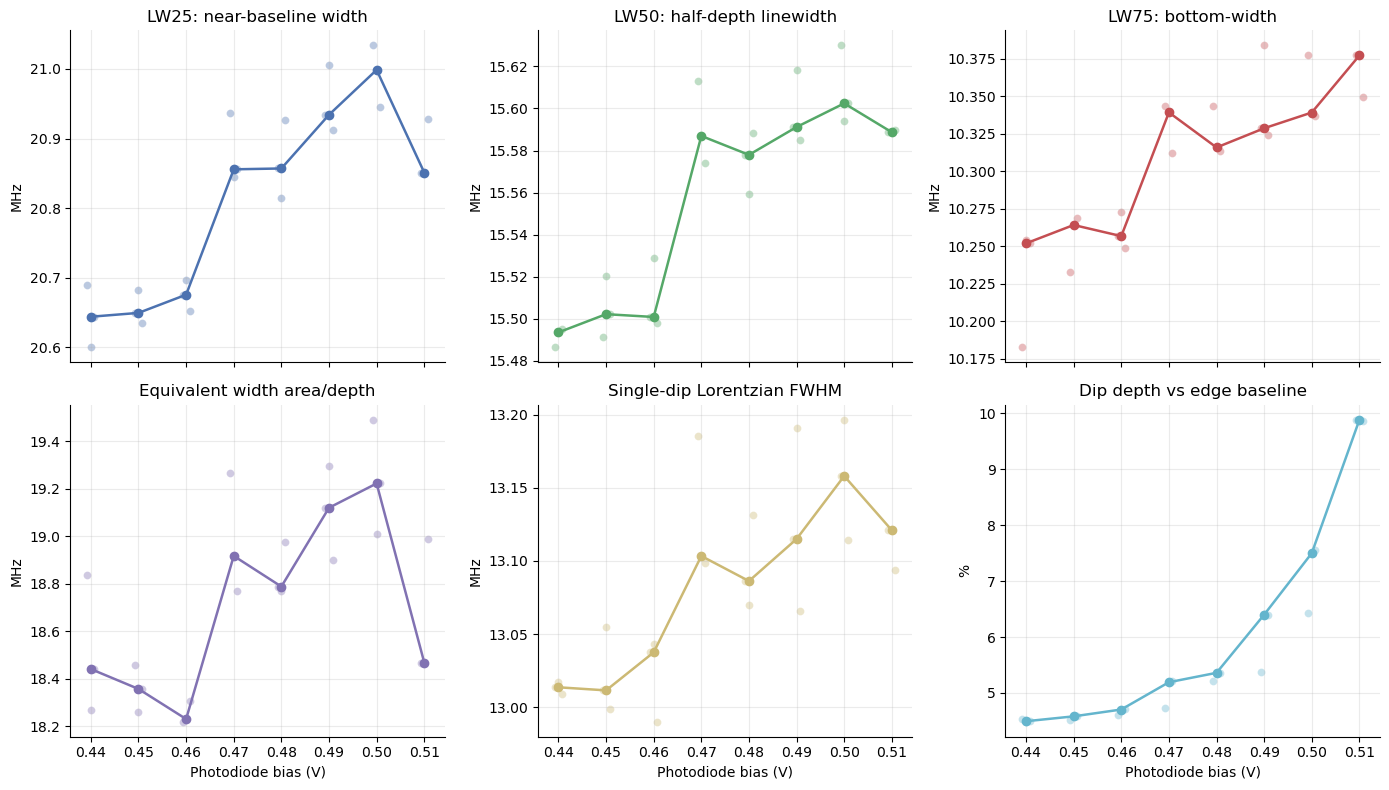

In [10]:

def _finite_labeled(rows, key):
    return [r for r in rows if np.isfinite(r.get('bias_v', np.nan)) and np.isfinite(r.get(key, np.nan))]


def _jittered_bias(rec):
    repeat = rec.get('repeat', np.nan)
    if np.isfinite(repeat):
        return rec['bias_v'] + (float(repeat) - 2.0) * 0.00075
    return rec['bias_v']


def _median_summary_xy(summary_rows, median_key):
    rows = [r for r in summary_rows if np.isfinite(r.get('bias_v', np.nan)) and np.isfinite(r.get(median_key, np.nan))]
    return np.array([r['bias_v'] for r in rows], dtype=float), np.array([r[median_key] for r in rows], dtype=float)


def plot_metric_vs_bias(ax, key, median_key, ylabel, title, color='#4C72B0', invert=False):
    rows = _finite_labeled(sweeps, key)
    ax.scatter([_jittered_bias(r) for r in rows], [r[key] for r in rows], s=32, color=color, alpha=0.38, edgecolor='white', linewidth=0.35)
    x_med, y_med = _median_summary_xy(advanced_summary, median_key)
    ax.plot(x_med, y_med, marker='o', color=color, lw=1.8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if invert:
        ax.invert_yaxis()


fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()
plot_metric_vs_bias(axes[0], 'adv_linewidth_25pct_mhz', 'adv_linewidth_25pct_mhz_median', 'MHz', 'LW25: near-baseline width', '#4C72B0')
plot_metric_vs_bias(axes[1], 'adv_linewidth_50pct_mhz', 'adv_linewidth_50pct_mhz_median', 'MHz', 'LW50: half-depth linewidth', '#55A868')
plot_metric_vs_bias(axes[2], 'adv_linewidth_75pct_mhz', 'adv_linewidth_75pct_mhz_median', 'MHz', 'LW75: bottom-width', '#C44E52')
plot_metric_vs_bias(axes[3], 'adv_equivalent_width_mhz', 'adv_equivalent_width_mhz_median', 'MHz', 'Equivalent width area/depth', '#8172B2')
plot_metric_vs_bias(axes[4], 'adv_lorentz_fwhm_mhz', 'adv_lorentz_fwhm_mhz_median', 'MHz', 'Single-dip Lorentzian FWHM', '#CCB974')
plot_metric_vs_bias(axes[5], 'adv_dip_depth_edge_percent', 'adv_dip_depth_edge_percent_median', '%', 'Dip depth vs edge baseline', '#64B5CD')
for ax in axes[3:]:
    ax.set_xlabel('Photodiode bias (V)')
plt.tight_layout()
plt.show()


## ODMR noise and SNR vs bias

These plots separate transmission noise from dip depth. Lower RMS/MAD/point-to-point noise and lower slope-limited frequency noise are better; higher dip SNR and slope-to-noise are better.


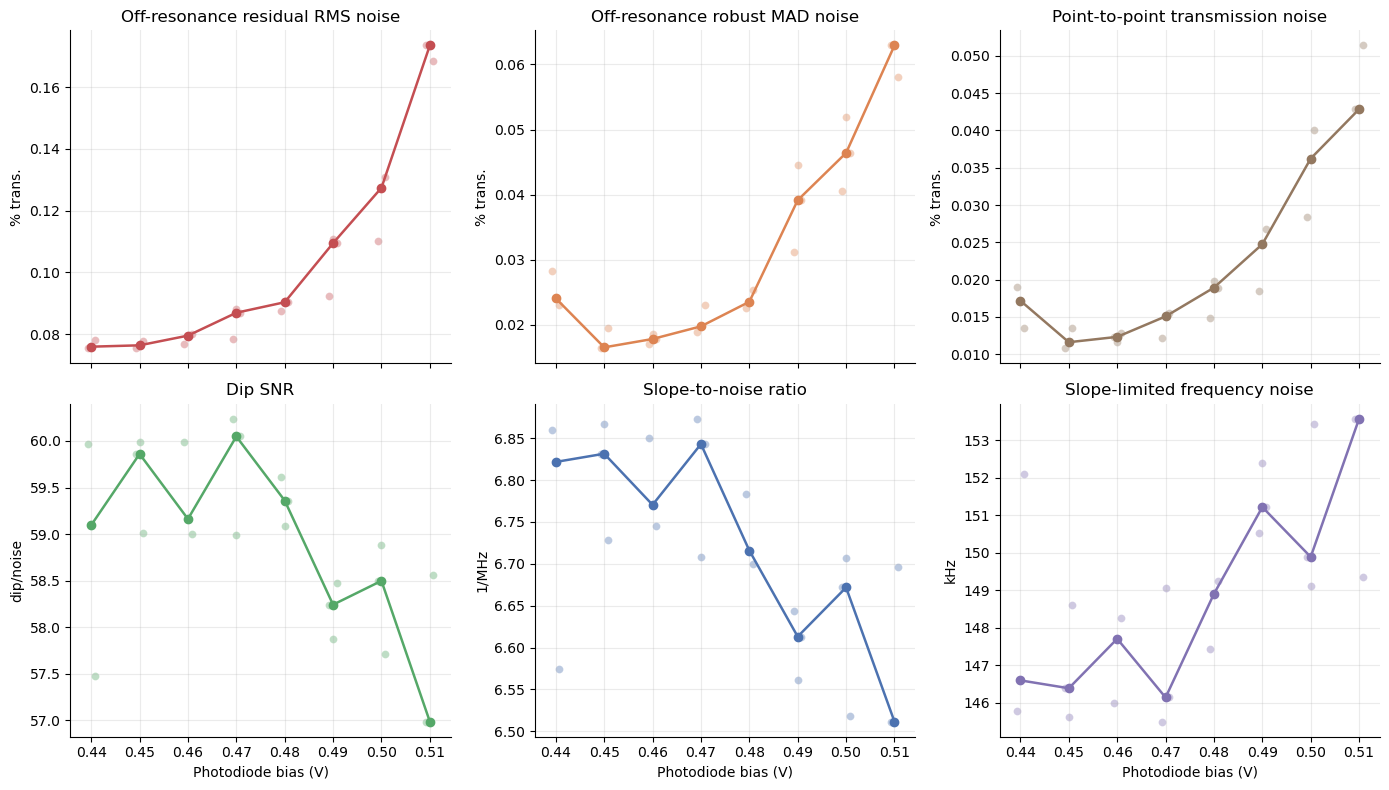

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()
plot_metric_vs_bias(axes[0], 'adv_residual_rms_noise_percent', 'adv_residual_rms_noise_percent_median', '% trans.', 'Off-resonance residual RMS noise', '#C44E52')
plot_metric_vs_bias(axes[1], 'adv_residual_mad_noise_percent', 'adv_residual_mad_noise_percent_median', '% trans.', 'Off-resonance robust MAD noise', '#DD8452')
plot_metric_vs_bias(axes[2], 'adv_point_to_point_noise_percent', 'adv_point_to_point_noise_percent_median', '% trans.', 'Point-to-point transmission noise', '#937860')
plot_metric_vs_bias(axes[3], 'adv_dip_snr', 'adv_dip_snr_median', 'dip/noise', 'Dip SNR', '#55A868')
plot_metric_vs_bias(axes[4], 'adv_slope_to_noise_per_mhz', 'adv_slope_to_noise_per_mhz_median', '1/MHz', 'Slope-to-noise ratio', '#4C72B0')
plot_metric_vs_bias(axes[5], 'adv_slope_limited_freq_noise_khz', 'adv_slope_limited_freq_noise_khz_median', 'kHz', 'Slope-limited frequency noise', '#8172B2')
for ax in axes[3:]:
    ax.set_xlabel('Photodiode bias (V)')
plt.tight_layout()
plt.show()


## Center frequency, asymmetry, and slopes vs bias

These plots check whether the ODMR transmission shape changes position or becomes asymmetric as photodiode bias changes. The left/right slope comparison is especially useful because sensitivity depends on usable slope as well as noise.


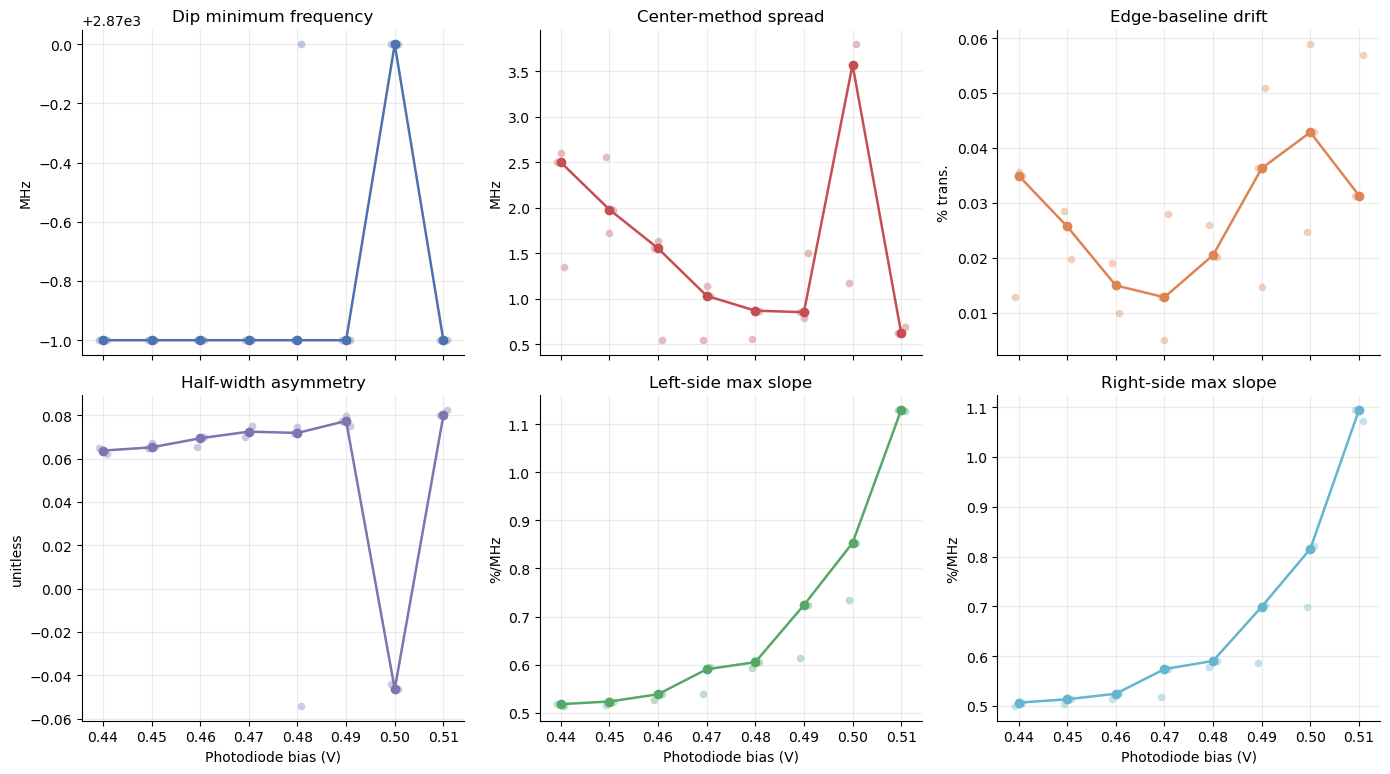

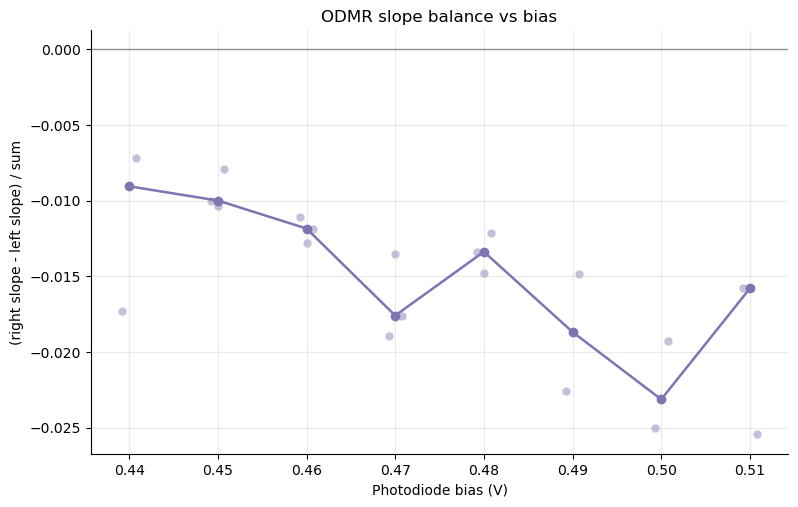

In [12]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()
plot_metric_vs_bias(axes[0], 'adv_center_min_mhz', 'adv_center_min_mhz_median', 'MHz', 'Dip minimum frequency', '#4C72B0')
plot_metric_vs_bias(axes[1], 'adv_center_method_spread_mhz', 'adv_center_method_spread_mhz_median', 'MHz', 'Center-method spread', '#C44E52')
plot_metric_vs_bias(axes[2], 'adv_abs_edge_baseline_drift_percent', 'adv_abs_edge_baseline_drift_percent_median', '% trans.', 'Edge-baseline drift', '#DD8452')
plot_metric_vs_bias(axes[3], 'adv_hwhm50_asymmetry', 'adv_hwhm50_asymmetry_median', 'unitless', 'Half-width asymmetry', '#8172B2')
plot_metric_vs_bias(axes[4], 'adv_left_slope_percent_per_mhz', 'adv_left_slope_percent_per_mhz_median', '%/MHz', 'Left-side max slope', '#55A868')
plot_metric_vs_bias(axes[5], 'adv_right_slope_percent_per_mhz', 'adv_right_slope_percent_per_mhz_median', '%/MHz', 'Right-side max slope', '#64B5CD')
for ax in axes[3:]:
    ax.set_xlabel('Photodiode bias (V)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
rows = _finite_labeled(sweeps, 'adv_slope_balance')
ax.axhline(0, color='0.3', lw=1, alpha=0.6)
ax.scatter([_jittered_bias(r) for r in rows], [r['adv_slope_balance'] for r in rows], s=38, color='#8172B2', alpha=0.45, edgecolor='white', linewidth=0.35)
x_med, y_med = _median_summary_xy(advanced_summary, 'adv_slope_balance_median')
ax.plot(x_med, y_med, marker='o', color='#8172B2', lw=1.8)
ax.set_xlabel('Photodiode bias (V)')
ax.set_ylabel('(right slope - left slope) / sum')
ax.set_title('ODMR slope balance vs bias')
plt.show()


## Advanced metric gallery vs bias

This compact gallery puts the main ODMR characterization metrics on the same bias axis. It is intended for quick trend scanning rather than final figure styling.


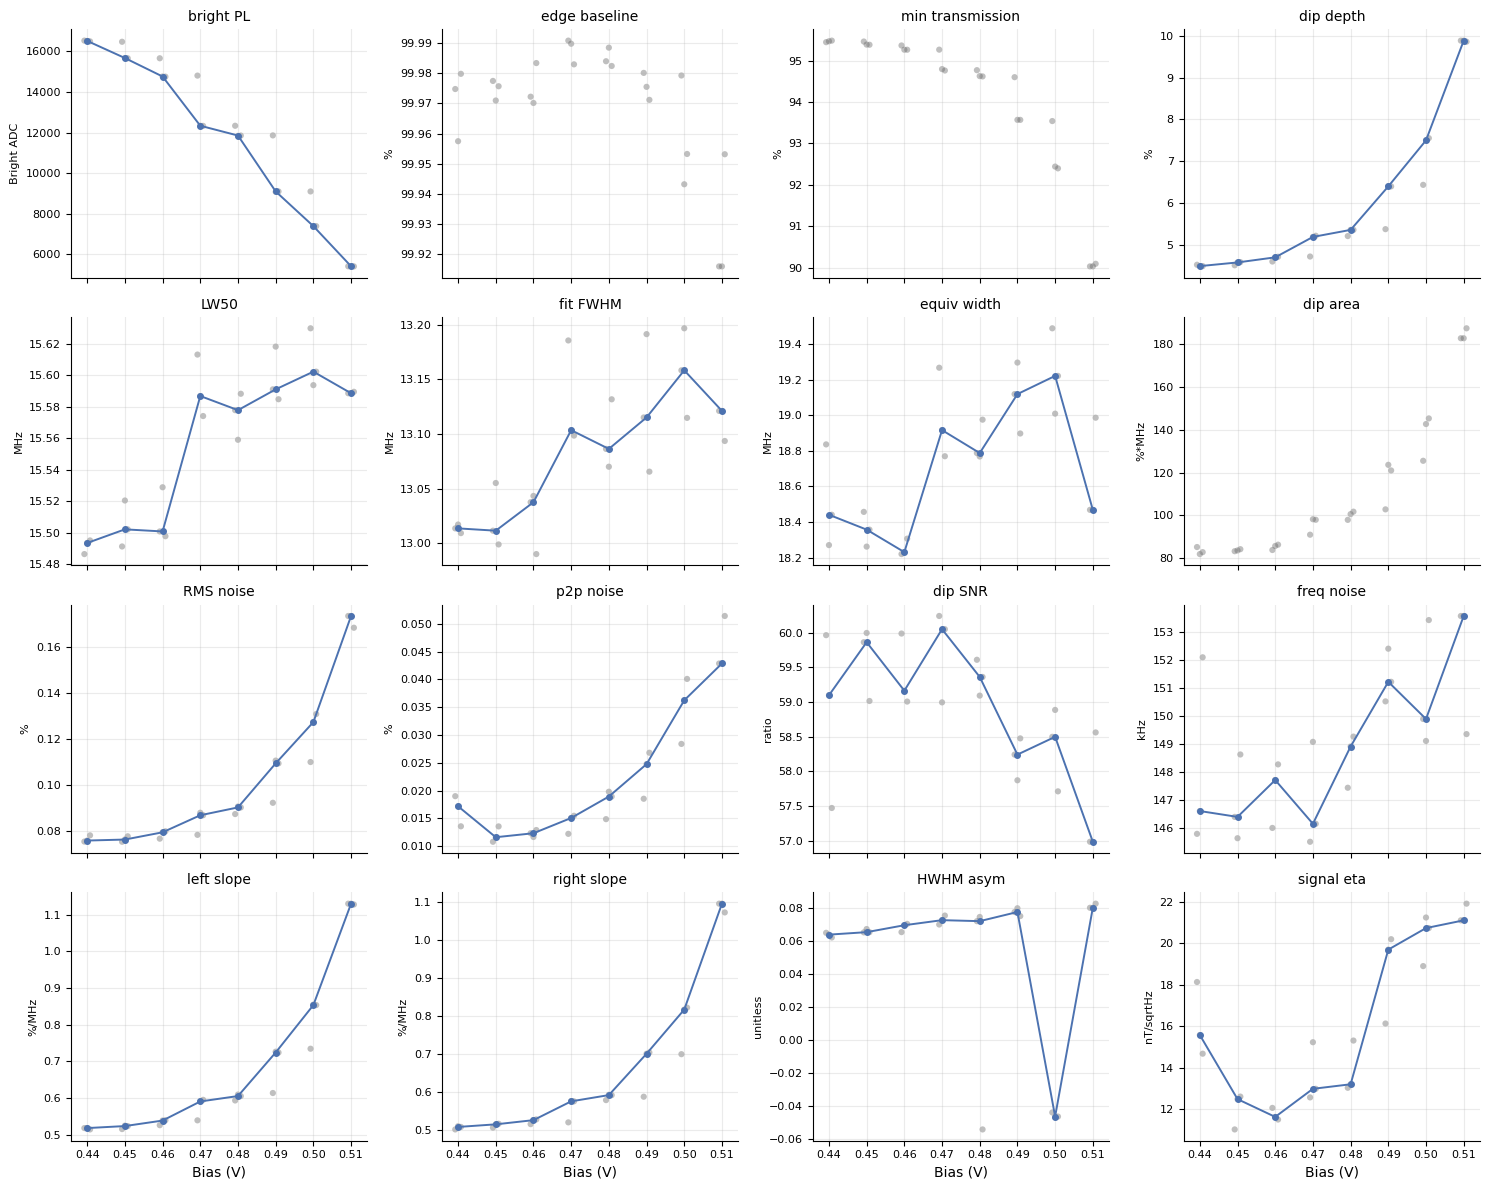

In [13]:

gallery_specs = [
    ('signal_bright_p90_adc', None, 'Bright ADC', 'bright PL'),
    ('adv_edge_baseline_percent', 'adv_edge_baseline_percent_median', '%', 'edge baseline'),
    ('adv_min_transmission_percent', 'adv_min_transmission_percent_median', '%', 'min transmission'),
    ('adv_dip_depth_edge_percent', 'adv_dip_depth_edge_percent_median', '%', 'dip depth'),
    ('adv_linewidth_50pct_mhz', 'adv_linewidth_50pct_mhz_median', 'MHz', 'LW50'),
    ('adv_lorentz_fwhm_mhz', 'adv_lorentz_fwhm_mhz_median', 'MHz', 'fit FWHM'),
    ('adv_equivalent_width_mhz', 'adv_equivalent_width_mhz_median', 'MHz', 'equiv width'),
    ('adv_area_edge_percent_mhz', 'adv_area_edge_percent_mhz_median', '%*MHz', 'dip area'),
    ('adv_residual_rms_noise_percent', 'adv_residual_rms_noise_percent_median', '%', 'RMS noise'),
    ('adv_point_to_point_noise_percent', 'adv_point_to_point_noise_percent_median', '%', 'p2p noise'),
    ('adv_dip_snr', 'adv_dip_snr_median', 'ratio', 'dip SNR'),
    ('adv_slope_limited_freq_noise_khz', 'adv_slope_limited_freq_noise_khz_median', 'kHz', 'freq noise'),
    ('adv_left_slope_percent_per_mhz', 'adv_left_slope_percent_per_mhz_median', '%/MHz', 'left slope'),
    ('adv_right_slope_percent_per_mhz', 'adv_right_slope_percent_per_mhz_median', '%/MHz', 'right slope'),
    ('adv_hwhm50_asymmetry', 'adv_hwhm50_asymmetry_median', 'unitless', 'HWHM asym'),
    ('robust_eta_baseline_nT', None, 'nT/sqrtHz', 'signal eta'),
]

numeric_summary_for_gallery = [r for r in bias_summary if np.isfinite(r['bias_v'])]
fig, axes = plt.subplots(4, 4, figsize=(15, 12), sharex=True)
axes = axes.ravel()
for ax, (key, median_key, ylabel, title) in zip(axes, gallery_specs):
    rows = _finite_labeled(sweeps, key)
    ax.scatter([_jittered_bias(r) for r in rows], [r[key] for r in rows], s=20, color='0.35', alpha=0.38, edgecolor='none')
    if median_key is not None:
        x_med, y_med = _median_summary_xy(advanced_summary, median_key)
        ax.plot(x_med, y_med, marker='o', color='#4C72B0', lw=1.4, ms=4)
    elif key == 'signal_bright_p90_adc':
        x_med = np.array([r['bias_v'] for r in numeric_summary_for_gallery], dtype=float)
        y_med = np.array([r['signal_bright_p90_median_adc'] for r in numeric_summary_for_gallery], dtype=float)
        ax.plot(x_med, y_med, marker='o', color='#4C72B0', lw=1.4, ms=4)
    elif key == 'robust_eta_baseline_nT':
        x_med = np.array([r['bias_v'] for r in numeric_summary_for_gallery], dtype=float)
        y_med = np.array([r['robust_signal_eta_median_nT'] for r in numeric_summary_for_gallery], dtype=float)
        ax.plot(x_med, y_med, marker='o', color='#4C72B0', lw=1.4, ms=4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=8)
for ax in axes[-4:]:
    ax.set_xlabel('Bias (V)')
plt.tight_layout()
plt.show()


## Advanced metric correlation map

This expands the earlier correlation map to include linewidth, noise, SNR, asymmetry, and fit diagnostics. It uses individual labeled-bias sweeps only.


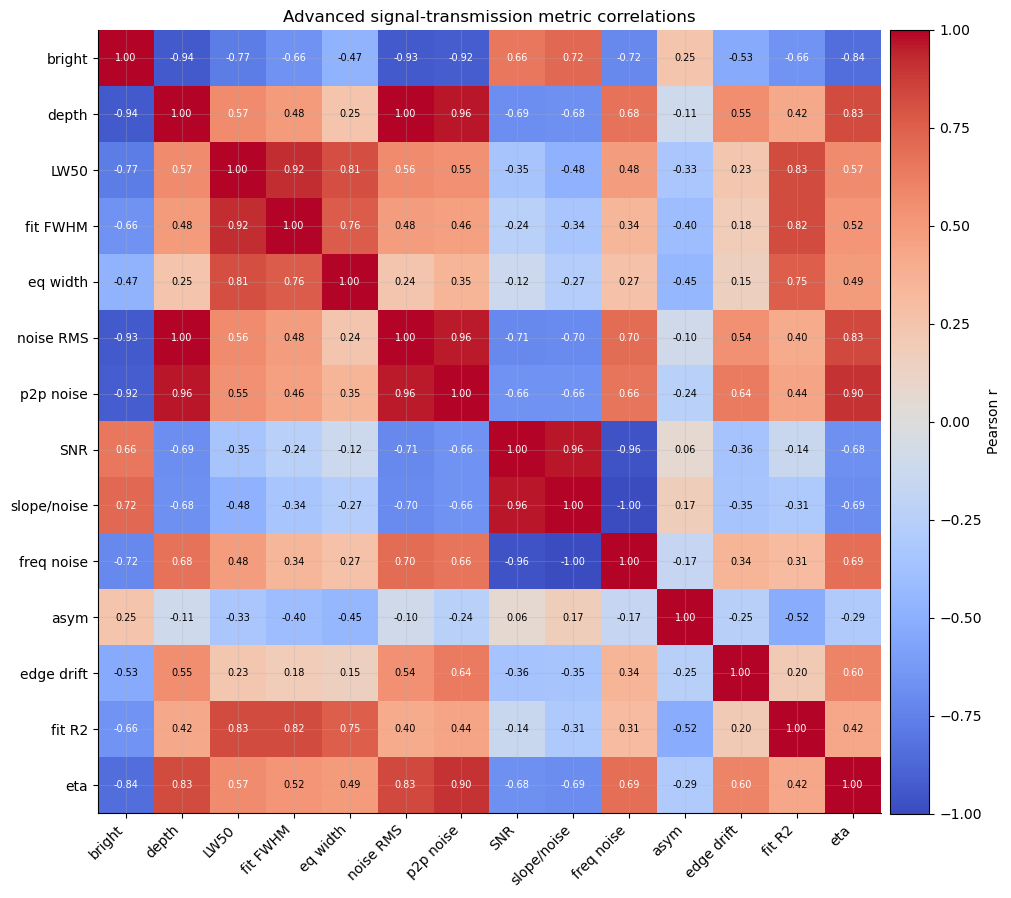

In [14]:

advanced_corr_specs = [
    ('signal_bright_p90_adc', 'bright'),
    ('adv_dip_depth_edge_percent', 'depth'),
    ('adv_linewidth_50pct_mhz', 'LW50'),
    ('adv_lorentz_fwhm_mhz', 'fit FWHM'),
    ('adv_equivalent_width_mhz', 'eq width'),
    ('adv_residual_rms_noise_percent', 'noise RMS'),
    ('adv_point_to_point_noise_percent', 'p2p noise'),
    ('adv_dip_snr', 'SNR'),
    ('adv_slope_to_noise_per_mhz', 'slope/noise'),
    ('adv_slope_limited_freq_noise_khz', 'freq noise'),
    ('adv_hwhm50_asymmetry', 'asym'),
    ('adv_abs_edge_baseline_drift_percent', 'edge drift'),
    ('adv_lorentz_r2', 'fit R2'),
    ('robust_eta_baseline_nT', 'eta'),
]
rows = [r for r in sweeps if np.isfinite(r.get('bias_v', np.nan))]
mat = np.asarray([[r.get(key, np.nan) for key, _ in advanced_corr_specs] for r in rows], dtype=float)
labels_adv_corr = [label for _, label in advanced_corr_specs]

corr = np.full((len(advanced_corr_specs), len(advanced_corr_specs)), np.nan)
for i in range(len(advanced_corr_specs)):
    for j in range(len(advanced_corr_specs)):
        xi, xj = mat[:, i], mat[:, j]
        mask = np.isfinite(xi) & np.isfinite(xj)
        if mask.sum() >= 3 and np.std(xi[mask]) > 0 and np.std(xj[mask]) > 0:
            corr[i, j] = np.corrcoef(xi[mask], xj[mask])[0, 1]

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(labels_adv_corr)))
ax.set_yticks(np.arange(len(labels_adv_corr)))
ax.set_xticklabels(labels_adv_corr, rotation=45, ha='right')
ax.set_yticklabels(labels_adv_corr)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if np.isfinite(corr[i, j]):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(corr[i, j]) > 0.55 else 'black')
ax.set_title('Advanced signal-transmission metric correlations')
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label('Pearson r')
plt.tight_layout()
plt.show()


## Lorentzian fit diagnostics and examples

The Lorentzian fit is only a diagnostic single-dip summary. If the fit R2 or residual worsens at a bias, trust the model-free linewidth/noise metrics first.


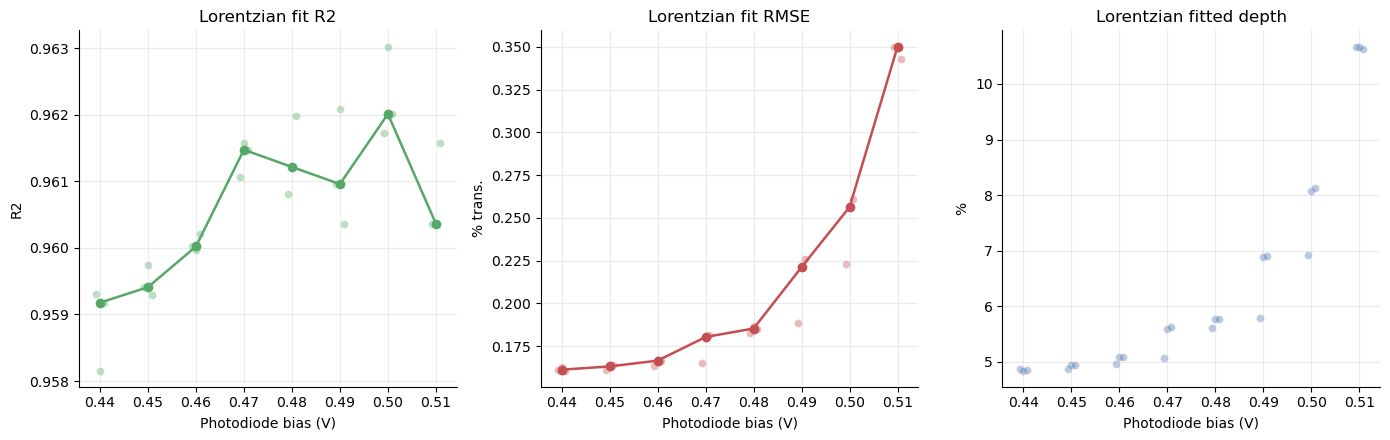

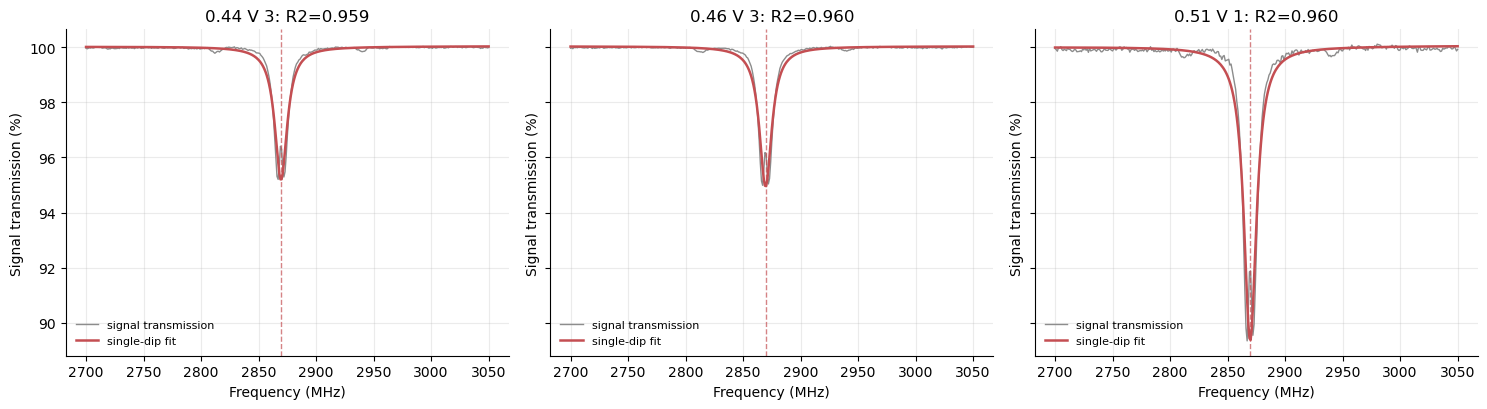

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True)
plot_metric_vs_bias(axes[0], 'adv_lorentz_r2', 'adv_lorentz_r2_median', 'R2', 'Lorentzian fit R2', '#55A868')
plot_metric_vs_bias(axes[1], 'adv_lorentz_rmse_percent', 'adv_lorentz_rmse_percent_median', '% trans.', 'Lorentzian fit RMSE', '#C44E52')
plot_metric_vs_bias(axes[2], 'adv_lorentz_depth_percent', 'adv_lorentz_depth_percent_median', '%', 'Lorentzian fitted depth', '#4C72B0')
for ax in axes:
    ax.set_xlabel('Photodiode bias (V)')
plt.tight_layout()
plt.show()

example_labels = []
for target in [0.44, 0.46, 0.51]:
    rows = [r for r in sweeps if np.isfinite(r['bias_v']) and abs(r['bias_v'] - target) < 1e-9]
    if rows:
        best = min(rows, key=lambda r: np.inf if not np.isfinite(r['robust_eta_baseline_nT']) else r['robust_eta_baseline_nT'])
        example_labels.append(best)

fig, axes = plt.subplots(1, len(example_labels), figsize=(5 * len(example_labels), 4.2), sharey=True)
if len(example_labels) == 1:
    axes = [axes]
for ax, rec in zip(axes, example_labels):
    cols = raw_by_file[rec['file']]
    freq = cols['frequency_MHz']
    sig = cols['photoluminescence_mw_on_ADC']
    trans = 100.0 * sig / np.percentile(sig, 90)
    fit = _lorentzian_dip(
        freq,
        rec['adv_lorentz_baseline_percent'],
        rec['adv_lorentz_baseline_slope_percent_per_mhz'],
        rec['adv_lorentz_depth_percent'],
        rec['adv_lorentz_center_mhz'],
        rec['adv_lorentz_gamma_mhz'],
    )
    ax.plot(freq, trans, color='0.55', lw=1, label='signal transmission')
    ax.plot(freq, fit, color='#C44E52', lw=1.8, label='single-dip fit')
    ax.axvline(rec['adv_lorentz_center_mhz'], color='#C44E52', lw=1, ls='--', alpha=0.7)
    ax.set_title(f"{rec['bias_label']} {rec['file'].split('_')[-1].replace('.csv','')}: R2={rec['adv_lorentz_r2']:.3f}")
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Signal transmission (%)')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


## Heatmap: every sweep as normalized signal transmission

Rows are sorted by bias and repeat. Darker rows around the ODMR resonance indicate lower signal transmission. This view makes it easier to see whether the dip deepens smoothly with bias and whether one repeat is unusual.


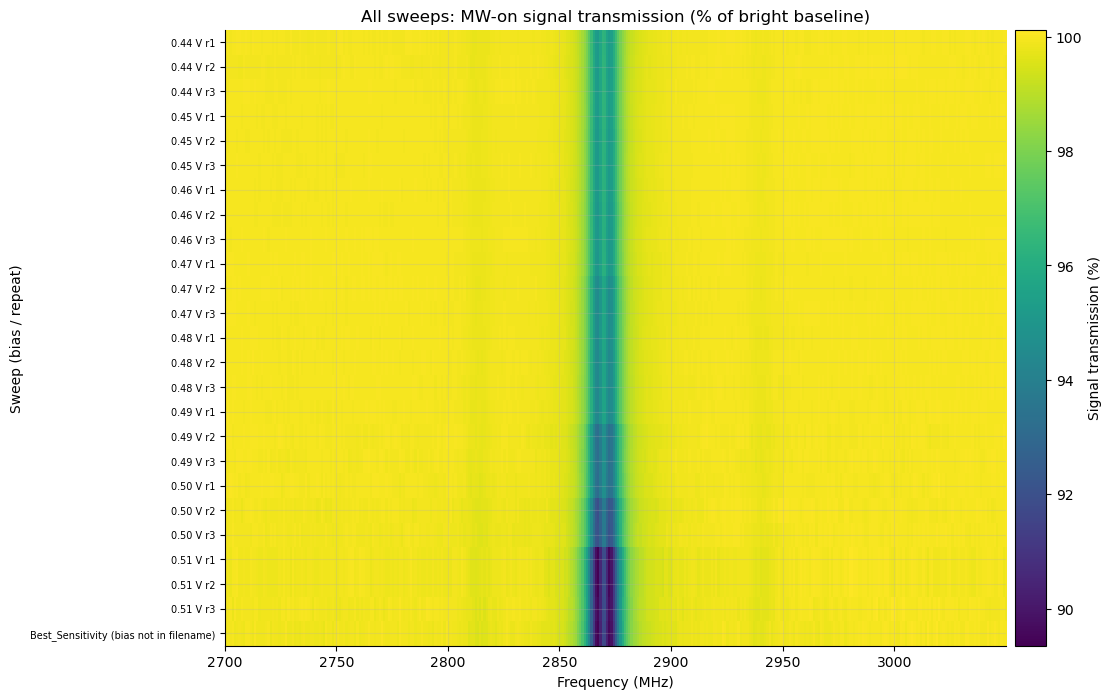

In [16]:

sorted_rows = ordered_sweeps
freq0 = raw_by_file[sorted_rows[0]['file']]['frequency_MHz']
heat = []
ylabels = []
for rec in sorted_rows:
    cols = raw_by_file[rec['file']]
    sig = cols['photoluminescence_mw_on_ADC']
    bright = np.percentile(sig, 90)
    heat.append(100.0 * sig / bright)
    rep = '' if not np.isfinite(rec['repeat']) else f" r{int(rec['repeat'])}"
    ylabels.append(f"{rec['bias_label']}{rep}")
heat = np.vstack(heat)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    heat,
    aspect='auto',
    interpolation='nearest',
    cmap='viridis',
    extent=[freq0.min(), freq0.max(), len(sorted_rows) - 0.5, -0.5],
)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Sweep (bias / repeat)')
ax.set_title('All sweeps: MW-on signal transmission (% of bright baseline)')
ax.set_yticks(np.arange(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=7)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label('Signal transmission (%)')
plt.show()


## Heatmap: bias-averaged signal transmission

This compresses repeats at each labeled bias into a single row. The unlabeled `Best_Sensitivity` run remains its own row.


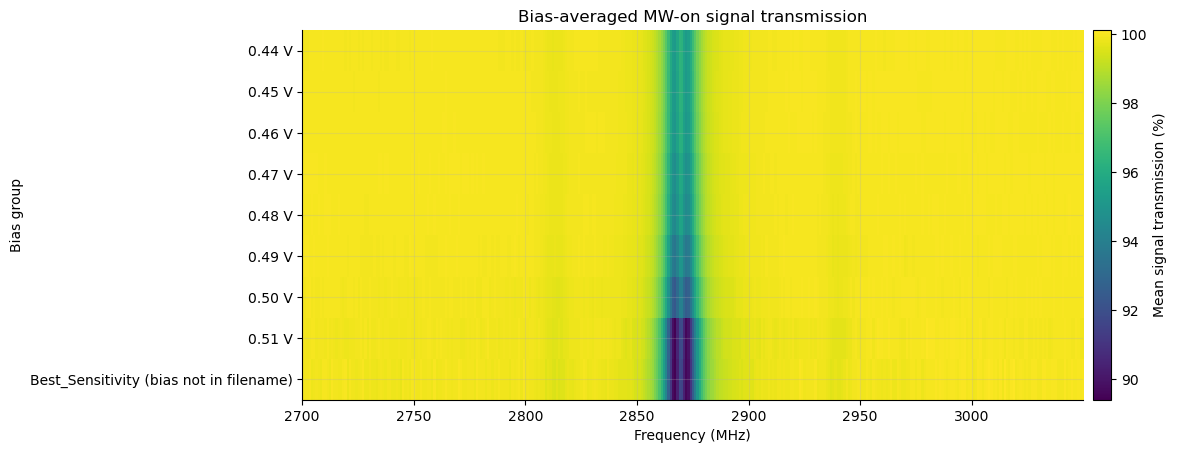

In [17]:

mean_rows = []
mean_labels = []
for label, rows in sorted(shape_groups.items(), key=group_sort_key):
    traces = []
    for rec in rows:
        cols = raw_by_file[rec['file']]
        sig = cols['photoluminescence_mw_on_ADC']
        traces.append(100.0 * sig / np.percentile(sig, 90))
    mean_rows.append(np.mean(np.vstack(traces), axis=0))
    mean_labels.append(label)
mean_heat = np.vstack(mean_rows)

fig, ax = plt.subplots(figsize=(12, 4.8))
im = ax.imshow(
    mean_heat,
    aspect='auto',
    interpolation='nearest',
    cmap='viridis',
    extent=[freq0.min(), freq0.max(), len(mean_labels) - 0.5, -0.5],
)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Bias group')
ax.set_title('Bias-averaged MW-on signal transmission')
ax.set_yticks(np.arange(len(mean_labels)))
ax.set_yticklabels(mean_labels)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label('Mean signal transmission (%)')
plt.show()


## Sensitivity components by bias

This separates sensitivity into the pieces that drive it: optical brightness, normalized ODMR slope, baseline noise, and final eta.


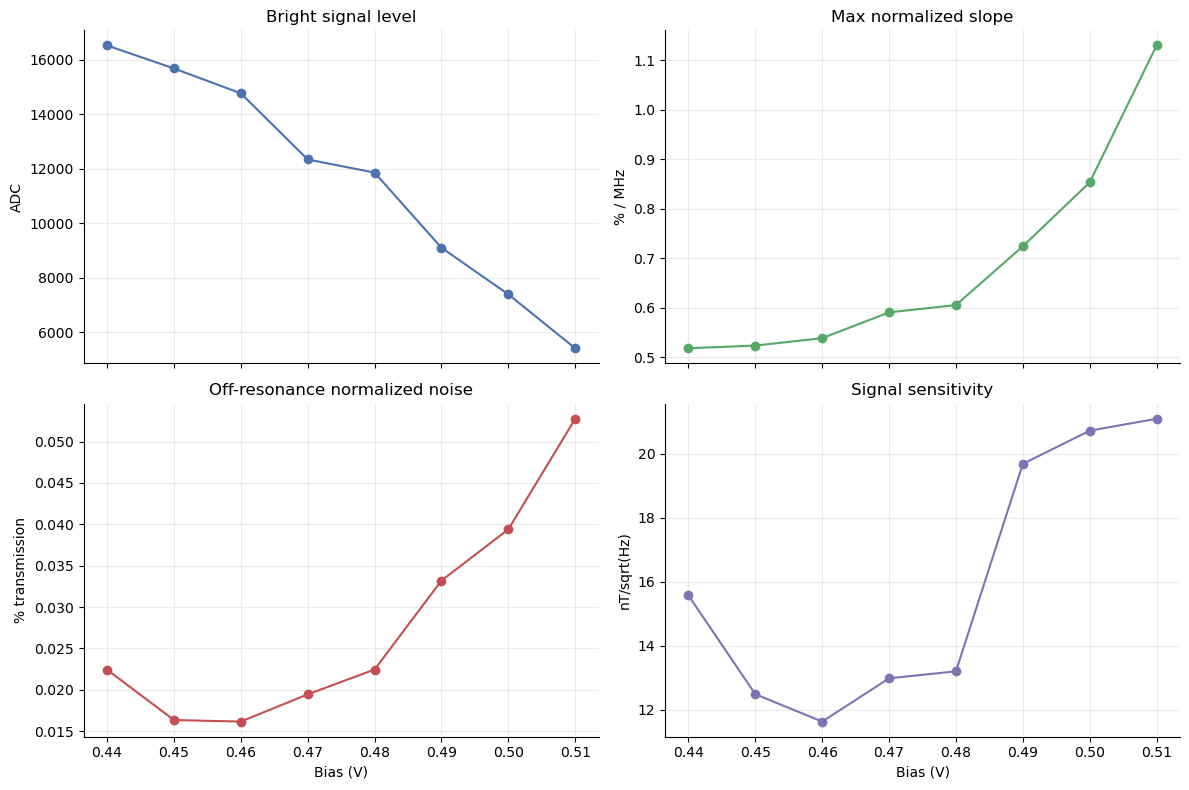

In [18]:

shape_numeric = [r for r in shape_summary if np.isfinite(r['bias_v'])]
x = np.array([r['bias_v'] for r in shape_numeric], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

axes[0].plot(x, [r['signal_bright_p90_median_adc'] for r in shape_numeric], marker='o', color='#4C72B0')
axes[0].set_ylabel('ADC')
axes[0].set_title('Bright signal level')

axes[1].plot(x, [r['shape_max_slope_median_percent_per_mhz'] for r in shape_numeric], marker='o', color='#55A868')
axes[1].set_ylabel('% / MHz')
axes[1].set_title('Max normalized slope')

axes[2].plot(x, [r['shape_off_noise_median_percent'] for r in shape_numeric], marker='o', color='#C44E52', label='shape off-noise')
axes[2].set_ylabel('% transmission')
axes[2].set_xlabel('Bias (V)')
axes[2].set_title('Off-resonance normalized noise')

axes[3].plot(x, [r['robust_signal_eta_median_nT'] for r in shape_numeric], marker='o', color='#8172B2')
axes[3].set_ylabel('nT/sqrt(Hz)')
axes[3].set_xlabel('Bias (V)')
axes[3].set_title('Signal sensitivity')

plt.tight_layout()
plt.show()


## Shape metrics by bias

These plots show whether the dip is becoming deeper, broader, or simply lower in PL as the photodiode bias changes.


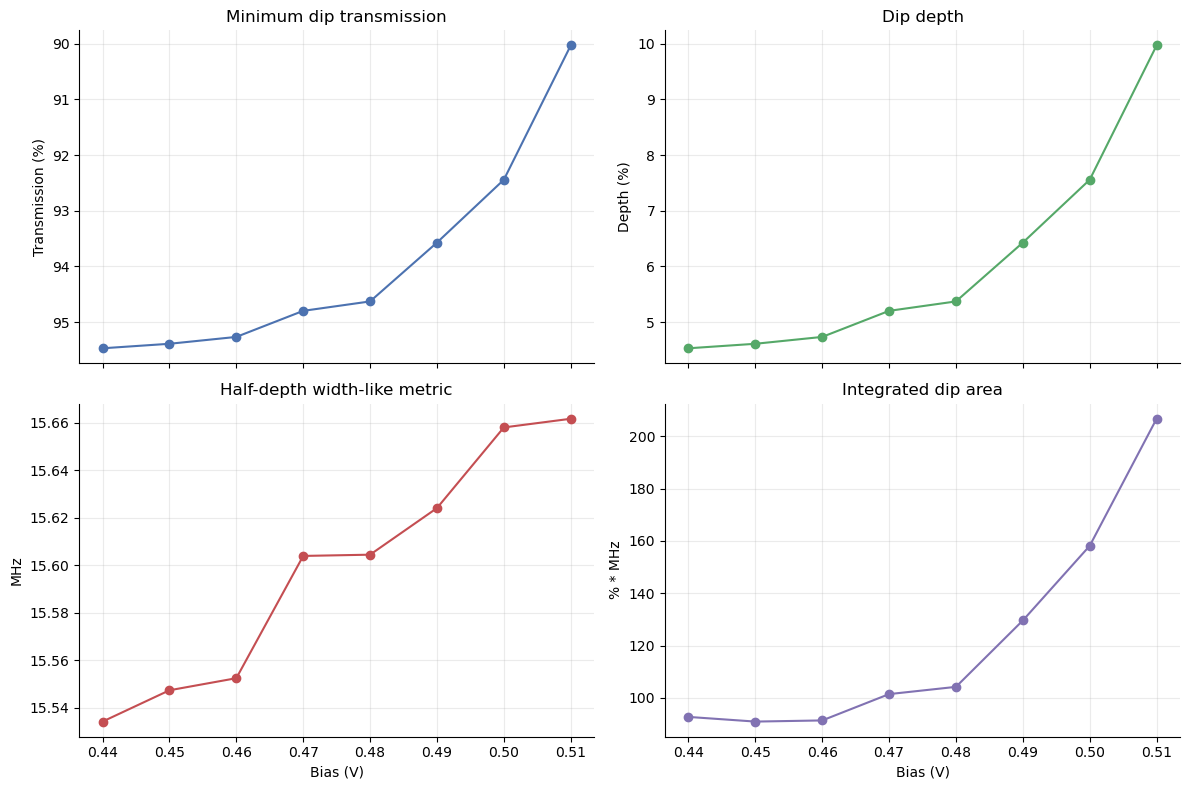

In [19]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

axes[0].plot(x, [r['shape_min_transmission_median_percent'] for r in shape_numeric], marker='o', color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_ylabel('Transmission (%)')
axes[0].set_title('Minimum dip transmission')

axes[1].plot(x, [r['shape_dip_depth_median_percent'] for r in shape_numeric], marker='o', color='#55A868')
axes[1].set_ylabel('Depth (%)')
axes[1].set_title('Dip depth')

axes[2].plot(x, [r['shape_fwhm_like_median_mhz'] for r in shape_numeric], marker='o', color='#C44E52')
axes[2].set_ylabel('MHz')
axes[2].set_xlabel('Bias (V)')
axes[2].set_title('Half-depth width-like metric')

axes[3].plot(x, [r['shape_area_median_percent_mhz'] for r in shape_numeric], marker='o', color='#8172B2')
axes[3].set_ylabel('% * MHz')
axes[3].set_xlabel('Bias (V)')
axes[3].set_title('Integrated dip area')

plt.tight_layout()
plt.show()


## Tradeoff scatter plots

Each point is one sweep. These views help distinguish “deeper dip” from “better sensitivity,” which are not identical because PL level and noise also matter.


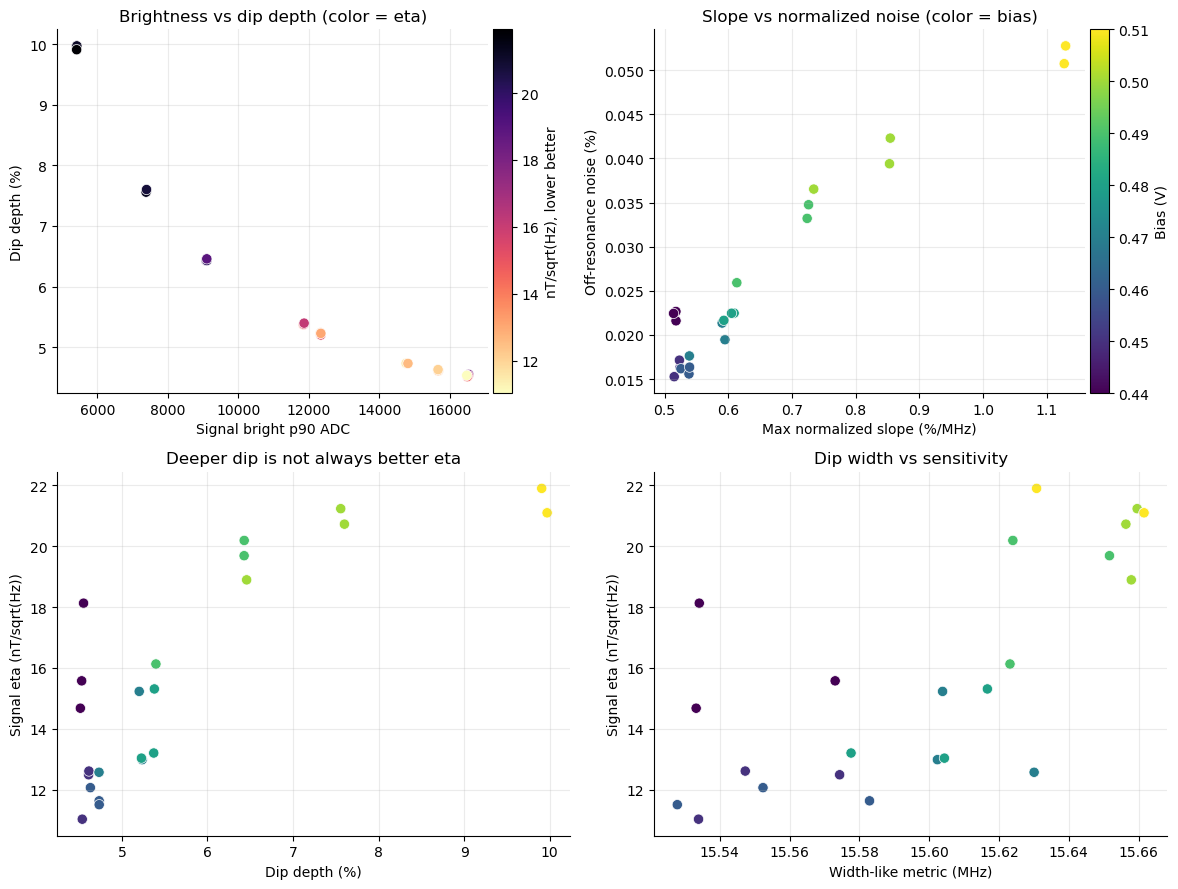

In [20]:

finite_sweeps = [r for r in sweeps if np.isfinite(r['bias_v']) and np.isfinite(r['robust_eta_baseline_nT'])]
bias_vals = np.array([r['bias_v'] for r in finite_sweeps], dtype=float)
eta_vals = np.array([r['robust_eta_baseline_nT'] for r in finite_sweeps], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

sc = axes[0].scatter(
    [r['signal_bright_p90_adc'] for r in finite_sweeps],
    [r['shape_dip_depth_percent'] for r in finite_sweeps],
    c=eta_vals, cmap='magma_r', s=55, edgecolor='white', linewidth=0.5,
)
axes[0].set_xlabel('Signal bright p90 ADC')
axes[0].set_ylabel('Dip depth (%)')
axes[0].set_title('Brightness vs dip depth (color = eta)')
cb = fig.colorbar(sc, ax=axes[0], pad=0.01)
cb.set_label('nT/sqrt(Hz), lower better')

sc = axes[1].scatter(
    [r['shape_max_slope_percent_per_mhz'] for r in finite_sweeps],
    [r['shape_off_noise_percent'] for r in finite_sweeps],
    c=bias_vals, cmap='viridis', s=55, edgecolor='white', linewidth=0.5,
)
axes[1].set_xlabel('Max normalized slope (%/MHz)')
axes[1].set_ylabel('Off-resonance noise (%)')
axes[1].set_title('Slope vs normalized noise (color = bias)')
cb = fig.colorbar(sc, ax=axes[1], pad=0.01)
cb.set_label('Bias (V)')

axes[2].scatter(
    [r['shape_dip_depth_percent'] for r in finite_sweeps],
    eta_vals,
    c=bias_vals, cmap='viridis', s=55, edgecolor='white', linewidth=0.5,
)
axes[2].set_xlabel('Dip depth (%)')
axes[2].set_ylabel('Signal eta (nT/sqrt(Hz))')
axes[2].set_title('Deeper dip is not always better eta')

axes[3].scatter(
    [r['shape_fwhm_like_mhz'] for r in finite_sweeps],
    eta_vals,
    c=bias_vals, cmap='viridis', s=55, edgecolor='white', linewidth=0.5,
)
axes[3].set_xlabel('Width-like metric (MHz)')
axes[3].set_ylabel('Signal eta (nT/sqrt(Hz))')
axes[3].set_title('Dip width vs sensitivity')

plt.tight_layout()
plt.show()


## Metric correlation map

This is a quick way to see which extracted metrics move together. Correlation uses individual labeled-bias sweeps only and ignores the unlabeled `Best_Sensitivity` run.


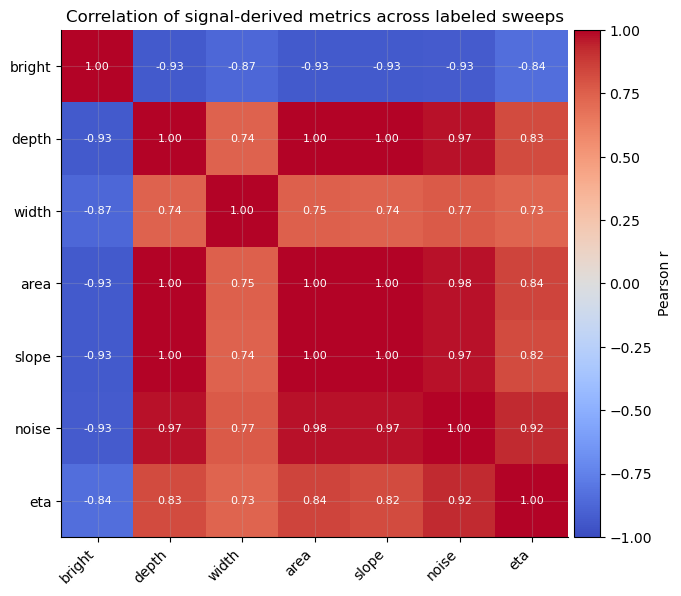

In [21]:

metric_specs = [
    ('signal_bright_p90_adc', 'bright'),
    ('shape_dip_depth_percent', 'depth'),
    ('shape_fwhm_like_mhz', 'width'),
    ('shape_area_percent_mhz', 'area'),
    ('shape_max_slope_percent_per_mhz', 'slope'),
    ('shape_off_noise_percent', 'noise'),
    ('robust_eta_baseline_nT', 'eta'),
]
mat_rows = []
for rec in finite_sweeps:
    mat_rows.append([rec[key] for key, _ in metric_specs])
mat = np.asarray(mat_rows, dtype=float)
labels_corr = [label for _, label in metric_specs]

corr = np.full((len(metric_specs), len(metric_specs)), np.nan)
for i in range(len(metric_specs)):
    for j in range(len(metric_specs)):
        xi, xj = mat[:, i], mat[:, j]
        mask = np.isfinite(xi) & np.isfinite(xj)
        if mask.sum() >= 3:
            corr[i, j] = np.corrcoef(xi[mask], xj[mask])[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(labels_corr)))
ax.set_yticks(np.arange(len(labels_corr)))
ax.set_xticklabels(labels_corr, rotation=45, ha='right')
ax.set_yticklabels(labels_corr)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if np.isfinite(corr[i, j]):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(corr[i, j]) > 0.55 else 'black')
ax.set_title('Correlation of signal-derived metrics across labeled sweeps')
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label('Pearson r')
plt.tight_layout()
plt.show()


## Repeat spread by bias

These bars show repeat-to-repeat variability. Large spread means the bias setting may be less reproducible even if one repeat looks good.


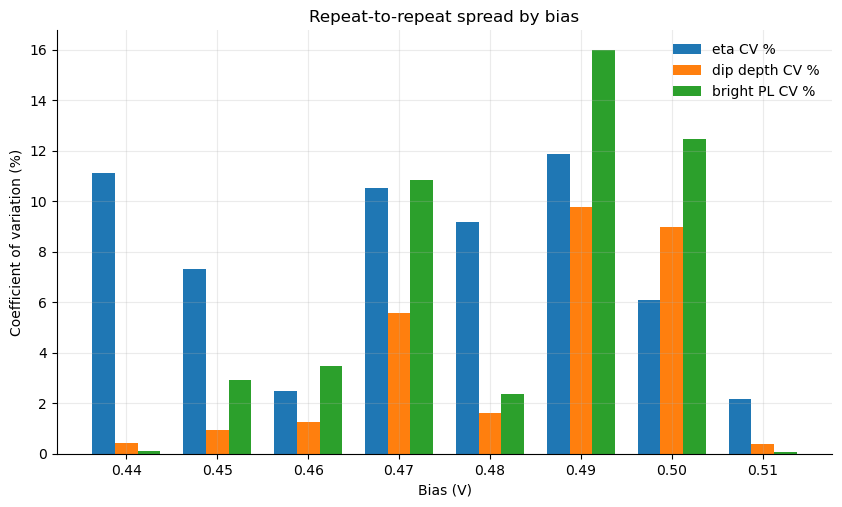

In [22]:

cv_rows = []
for label, rows in sorted(shape_groups.items(), key=group_sort_key):
    if not np.isfinite(rows[0]['bias_v']) or len(rows) < 2:
        continue
    def cv(key):
        vals = np.asarray([r[key] for r in rows], dtype=float)
        vals = vals[np.isfinite(vals)]
        return float(100.0 * np.std(vals, ddof=1) / np.mean(vals)) if len(vals) >= 2 and np.mean(vals) != 0 else np.nan
    cv_rows.append({
        'bias_v': rows[0]['bias_v'],
        'eta_cv_percent': cv('robust_eta_baseline_nT'),
        'depth_cv_percent': cv('shape_dip_depth_percent'),
        'bright_cv_percent': cv('signal_bright_p90_adc'),
    })

fig, ax = plt.subplots(figsize=(10, 5.5))
x_cv = np.array([r['bias_v'] for r in cv_rows])
width = 0.0025
ax.bar(x_cv - width, [r['eta_cv_percent'] for r in cv_rows], width=width, label='eta CV %')
ax.bar(x_cv, [r['depth_cv_percent'] for r in cv_rows], width=width, label='dip depth CV %')
ax.bar(x_cv + width, [r['bright_cv_percent'] for r in cv_rows], width=width, label='bright PL CV %')
ax.set_xlabel('Bias (V)')
ax.set_ylabel('Coefficient of variation (%)')
ax.set_title('Repeat-to-repeat spread by bias')
ax.legend(frameon=False)
plt.show()


## Signal dip transmission traces by bias

Each MW-on signal trace is normalized to its own bright baseline (`signal_bright_p90_adc`). This makes the ODMR dip transmission directly comparable across bias voltages even though the absolute PL level changes strongly with bias.


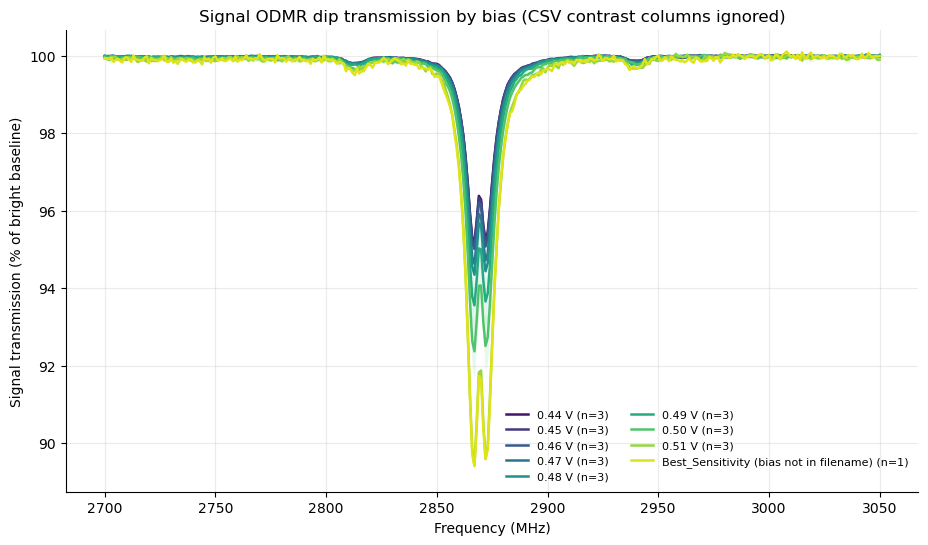

In [23]:

fig, ax = plt.subplots(figsize=(11, 6))
labels = [label for label, _ in sorted(groups.items(), key=group_sort_key)]
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(labels)))

for color, label in zip(colors, labels):
    rows = groups[label]
    traces = []
    freqs = []
    for row in rows:
        cols = raw_by_file[row['file']]
        sig = cols['photoluminescence_mw_on_ADC']
        bright = np.percentile(sig, 90)
        freqs.append(cols['frequency_MHz'])
        traces.append(100.0 * sig / bright)
    x = freqs[0]
    y = np.vstack(traces)
    mean = np.mean(y, axis=0)
    sd = np.std(y, axis=0, ddof=1) if len(traces) > 1 else np.zeros_like(mean)
    ax.plot(x, mean, lw=1.8, color=color, label=f'{label} (n={len(rows)})')
    if len(traces) > 1:
        ax.fill_between(x, mean - sd, mean + sd, color=color, alpha=0.12, linewidth=0)

ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Signal transmission (% of bright baseline)')
ax.set_title('Signal ODMR dip transmission by bias (CSV contrast columns ignored)')
ax.legend(ncol=2, fontsize=8, frameon=False)
plt.show()


## Bias trends: signal brightness, dip transmission, and signal sensitivity


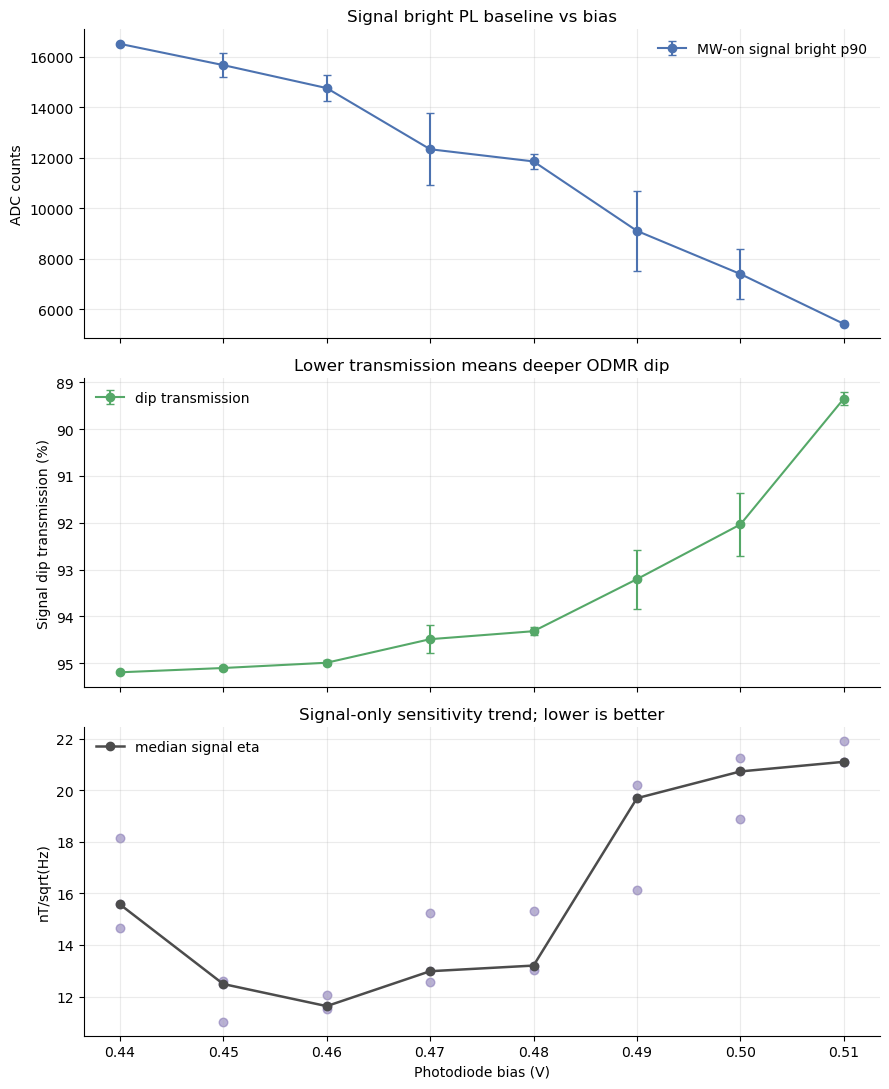

In [24]:

numeric_summary = [r for r in bias_summary if np.isfinite(r['bias_v'])]
x = np.array([r['bias_v'] for r in numeric_summary], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

axes[0].errorbar(
    x,
    [r['signal_bright_p90_median_adc'] for r in numeric_summary],
    yerr=[0 if not np.isfinite(r['signal_bright_p90_sd_adc']) else r['signal_bright_p90_sd_adc'] for r in numeric_summary],
    marker='o', capsize=3, color='#4C72B0', label='MW-on signal bright p90',
)
axes[0].set_ylabel('ADC counts')
axes[0].set_title('Signal bright PL baseline vs bias')
axes[0].legend(frameon=False)

axes[1].errorbar(
    x,
    [r['signal_dip_transmission_median_percent'] for r in numeric_summary],
    yerr=[0 if not np.isfinite(r['signal_dip_transmission_sd_percent']) else r['signal_dip_transmission_sd_percent'] for r in numeric_summary],
    marker='o', capsize=3, color='#55A868', label='dip transmission',
)
axes[1].invert_yaxis()
axes[1].set_ylabel('Signal dip transmission (%)')
axes[1].set_title('Lower transmission means deeper ODMR dip')
axes[1].legend(frameon=False)

for rec in sweeps:
    if np.isfinite(rec['bias_v']) and np.isfinite(rec['robust_eta_baseline_nT']):
        axes[2].scatter(rec['bias_v'], rec['robust_eta_baseline_nT'], s=38, color='#8172B2', alpha=0.55)
axes[2].plot(x, [r['robust_signal_eta_median_nT'] for r in numeric_summary], marker='o', color='#4C4C4C', lw=1.8, label='median signal eta')
axes[2].set_ylabel('nT/sqrt(Hz)')
axes[2].set_xlabel('Photodiode bias (V)')
axes[2].set_title('Signal-only sensitivity trend; lower is better')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


## Quick signal sensitivity vs robust signal sensitivity

The quick signal estimate is the default structure-aware helper restricted to the signal trace. The robust batch estimate is also signal-only, but retries with a smaller off-resonance guard if the default guard leaves too few clean baseline points.


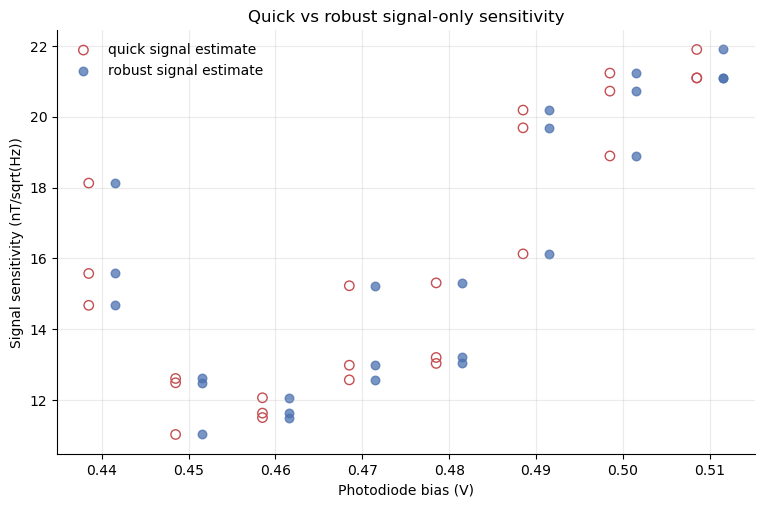

No default quick signal estimates had fewer than 10 clean baseline points.


In [25]:

fig, ax = plt.subplots(figsize=(9, 5.5))
for rec in sweeps:
    if not np.isfinite(rec['bias_v']):
        continue
    if np.isfinite(rec['quick_eta_baseline_nT']):
        ax.scatter(rec['bias_v'] - 0.0015, rec['quick_eta_baseline_nT'], marker='o', facecolors='none', edgecolors='#C44E52', s=46, label='quick signal estimate' if 'quick signal estimate' not in ax.get_legend_handles_labels()[1] else None)
    if np.isfinite(rec['robust_eta_baseline_nT']):
        ax.scatter(rec['bias_v'] + 0.0015, rec['robust_eta_baseline_nT'], marker='o', color='#4C72B0', s=38, alpha=0.75, label='robust signal estimate' if 'robust signal estimate' not in ax.get_legend_handles_labels()[1] else None)
ax.set_xlabel('Photodiode bias (V)')
ax.set_ylabel('Signal sensitivity (nT/sqrt(Hz))')
ax.set_title('Quick vs robust signal-only sensitivity')
ax.legend(frameon=False)
plt.show()

suspicious = [r for r in ordered_sweeps if np.isfinite(r['quick_n_clean']) and r['quick_n_clean'] < MIN_CLEAN_POINTS]
if suspicious:
    display(HTML('<h4>Sweeps where default quick signal estimate had too few clean baseline points</h4>' + html_table(suspicious, sweep_cols)))
else:
    print('No default quick signal estimates had fewer than', MIN_CLEAN_POINTS, 'clean baseline points.')


## Best sweeps by signal sensitivity


In [26]:

ranked = sorted(
    sweeps,
    key=lambda r: np.inf if not np.isfinite(r['robust_eta_baseline_nT']) else r['robust_eta_baseline_nT'],
)
rank_cols = [
    ('robust_eta_baseline_nT', 'robust signal eta nT/sqrtHz', 2),
    ('quick_eta_baseline_nT', 'quick signal eta nT/sqrtHz', 2),
    ('bias_label', 'bias', 0),
    ('repeat', 'rep', 0),
    ('robust_f_at_slope_mhz', 'operate MHz', 1),
    ('signal_dip_transmission_percent', 'dip transmission %', 3),
    ('signal_dip_depth_percent', 'dip depth %', 3),
    ('signal_bright_p90_adc', 'signal bright p90 ADC', 1),
    ('file', 'file', 0),
]
display(HTML(html_table(ranked, rank_cols, max_rows=12)))


robust signal eta nT/sqrtHz,quick signal eta nT/sqrtHz,bias,rep,operate MHz,dip transmission %,dip depth %,signal bright p90 ADC,file
11.03,11.03,0.45 V,1,2864.2,95.185,4.815,16476.0,odmr_sweep_20260707_112159_0.45VBias_1.csv
11.50,11.50,0.46 V,3,2864.2,94.991,5.009,14756.9,odmr_sweep_20260707_112342_0.46VBias_3.csv
11.63,11.63,0.46 V,2,2864.2,94.974,5.026,14763.6,odmr_sweep_20260707_112324_0.46VBias_2.csv
12.06,12.06,0.46 V,1,2864.1,95.076,4.924,15662.7,odmr_sweep_20260707_112300_0.46VBias_1.csv
12.49,12.49,0.45 V,2,2864.2,95.094,4.906,15674.5,odmr_sweep_20260707_112219_0.45VBias_2.csv
12.57,12.57,0.47 V,1,2864.2,94.973,5.027,14808.9,odmr_sweep_20260707_112418_0.47VBias_1.csv
12.61,12.61,0.45 V,3,2864.2,95.103,4.897,15663.3,odmr_sweep_20260707_112234_0.45VBias_3.csv
12.98,12.98,0.47 V,3,2864.2,94.439,5.561,12331.0,odmr_sweep_20260707_112454_0.47VBias_3.csv
13.03,13.03,0.48 V,1,2864.2,94.442,5.558,12338.3,odmr_sweep_20260707_112528_0.48VBias_1.csv
13.20,13.20,0.48 V,2,2864.2,94.318,5.682,11839.3,odmr_sweep_20260707_112550_0.48VBias_2.csv


## Interpretation notes

- This notebook does **not** use `contrast_ADC` or `contrast_percent`; all ODMR ranking is signal-trace based.
- Best labeled voltage by median signal sensitivity is the safest bias recommendation because it uses all repeats.
- As bias increases, the signal dip becomes deeper in percent transmission, but bright PL drops. The best sensitivity sits where slope, noise, linewidth, and PL are balanced, not necessarily where the transmission dip is deepest.
- The advanced transmission metrics are model-free except the columns beginning with `adv_lorentz_`; use Lorentzian fit diagnostics as a quick linewidth check, not as the only truth.
- The unlabeled `Best_Sensitivity` file should be mapped back to the lab setting before making a bias-voltage statement from it.


In [27]:

finite_numeric = [r for r in bias_summary if np.isfinite(r['bias_v']) and np.isfinite(r['robust_signal_eta_median_nT'])]
best_bias = min(finite_numeric, key=lambda r: r['robust_signal_eta_median_nT']) if finite_numeric else None
best_single = min(ranked, key=lambda r: np.inf if not np.isfinite(r['robust_eta_baseline_nT']) else r['robust_eta_baseline_nT'])
advanced_numeric = [r for r in advanced_summary if np.isfinite(r['bias_v'])] if 'advanced_summary' in globals() else []

print('Signal-only summary:')
if best_bias:
    print(f"  Best labeled bias by median signal eta: {best_bias['bias_label']} -> {best_bias['robust_signal_eta_median_nT']:.2f} nT/sqrt(Hz)")
    print(f"  Best repeat in that group: {best_bias['best_repeat_file']}")
print(f"  Best single sweep by signal eta: {best_single['file']} -> {best_single['robust_eta_baseline_nT']:.2f} nT/sqrt(Hz) ({best_single['bias_label']})")
print(f"  Lowest labeled-bias median dip transmission: {min(finite_numeric, key=lambda r: r['signal_dip_transmission_median_percent'])['bias_label']}")
if advanced_numeric:
    lowest_noise = min(advanced_numeric, key=lambda r: r['adv_residual_rms_noise_percent_median'])
    narrowest = min(advanced_numeric, key=lambda r: r['adv_linewidth_50pct_mhz_median'])
    best_snr = max(advanced_numeric, key=lambda r: r['adv_dip_snr_median'])
    print(f"  Lowest median transmission RMS noise: {lowest_noise['bias_label']} -> {lowest_noise['adv_residual_rms_noise_percent_median']:.4f} %")
    print(f"  Narrowest median LW50 linewidth: {narrowest['bias_label']} -> {narrowest['adv_linewidth_50pct_mhz_median']:.2f} MHz")
    print(f"  Highest median dip SNR: {best_snr['bias_label']} -> {best_snr['adv_dip_snr_median']:.1f}")
print(f"  Sweep metrics CSV: {sweep_csv}")
print(f"  Bias summary CSV: {bias_csv}")
if 'advanced_sweep_csv' in globals():
    print(f"  Advanced sweep metrics CSV: {advanced_sweep_csv}")
    print(f"  Advanced bias summary CSV: {advanced_bias_csv}")


Signal-only summary:
  Best labeled bias by median signal eta: 0.46 V -> 11.63 nT/sqrt(Hz)
  Best repeat in that group: odmr_sweep_20260707_112342_0.46VBias_3.csv
  Best single sweep by signal eta: odmr_sweep_20260707_112159_0.45VBias_1.csv -> 11.03 nT/sqrt(Hz) (0.45 V)
  Lowest labeled-bias median dip transmission: 0.51 V
  Lowest median transmission RMS noise: 0.44 V -> 0.0759 %
  Narrowest median LW50 linewidth: 0.44 V -> 15.49 MHz
  Highest median dip SNR: 0.47 V -> 60.0
  Sweep metrics CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_sweep_metrics.csv
  Bias summary CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/notebooks/odmr_post_saturation_fix_bias_summary.csv
  Advanced sweep metrics CSV: /Users/ckasemtantikul/Library/CloudStorage/O